<a href="https://colab.research.google.com/github/rakhujoy/Wind-Forecasting-2026/blob/main/Wind_Forecasting_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyinform
!pip install torch torch_geometric
!pip install ts2vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import zipfile
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import torch

print(torch.cuda.is_available())   # Should be True
print(torch.cuda.device_count())   # Number of GPUs
# print(torch.cuda.get_device_name(0))  # GPU name

True
1


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Path to your ZIP file
folder_path = "/content/drive/MyDrive/Wind 2026/"

Mounted at /content/drive


In [ ]:
df_list = []   # list to store all dataframes

for file in os.listdir(folder_path):
    if file.endswith(".zip"):
        zip_path = os.path.join(folder_path, file)

        with zipfile.ZipFile(zip_path, 'r') as z:
            csv_files = [f for f in z.namelist() if f.endswith(".csv")]

            for csv_file in csv_files:
                with z.open(csv_file) as f:
                    df = pd.read_csv(f)

                df_list.append(df)


In [ ]:
def process_site(df):
    # Drop columns with NaNs
    df = df.dropna(axis=1)

    # Add wind speed column
    df["wind_speed"] = np.sqrt(df["u100"]**2 + df["v100"]**2)

    # Debug info (optional)
    print("Shape:", df.shape)
    # print("NaNs:\n", df.isna().sum())
    print("-" * 40)

    return df

/tmp/ipykernel_1256/1766921447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["wind_speed"] = np.sqrt(df["u100"]**2 + df["v100"]**2)
/tmp/ipykernel_1256/1766921447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["wind_speed"] = np.sqrt(df["u100"]**2 + df["v100"]**2)
/tmp/ipykernel_1256/1766921447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 20)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------


/tmp/ipykernel_1256/646999698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site["valid_time"] = pd.to_datetime(site["valid_time"])
/tmp/ipykernel_1256/646999698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site["valid_time"] = pd.to_datetime(site["valid_time"])
/tmp/ipykernel_1256/646999698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

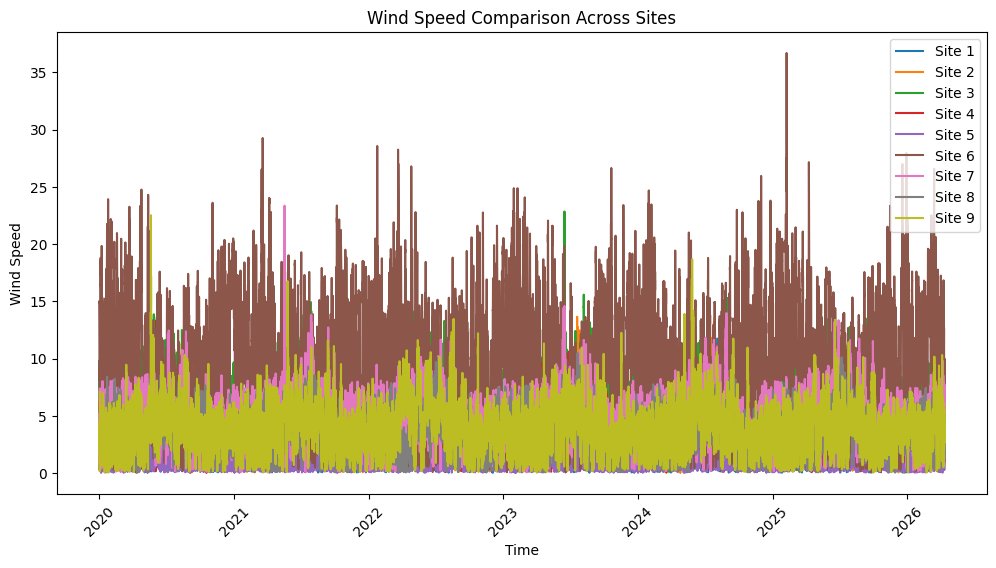

In [ ]:
site1= process_site(df_list[0])
site2= process_site(df_list[2])
site3= process_site(df_list[4])
site4= process_site(df_list[6])
site5= process_site(df_list[8])
site6= process_site(df_list[10])
site7= process_site(df_list[12])
site8= process_site(df_list[14])
site9= process_site(df_list[16])
plt.figure(figsize=(12, 6))

for i, site in enumerate([site1, site2, site3, site4, site5, site6, site7, site8, site9]):
    # Ensure time is datetime & sorted
    site["valid_time"] = pd.to_datetime(site["valid_time"])
    site = site.sort_values("valid_time")

    sns.lineplot(
        x=site["valid_time"],
        y=site["wind_speed"],
        label=f"Site {i+1}"
    )

plt.title("Wind Speed Comparison Across Sites")
plt.xlabel("Time")
plt.ylabel("Wind Speed")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
site1.columns


Index(['valid_time', 'u100', 'v100', 'u10', 'v10', 'fg10', 'd2m', 't2m', 'blh',
       'msl', 'skt', 'sp', 'ssrd', 'strd', 'tcc', 'tp', 'latitude',
       'longitude', 'wind_speed'],
      dtype='object')

Processing site_1...
Processing site_2...
Processing site_3...
Processing site_4...
Processing site_5...
Processing site_6...
Processing site_7...
Processing site_8...
Processing site_9...

Transfer Entropy Results:
        site_1    site_2    site_3    site_4    site_5    site_6    site_7  \
u100  0.008272  0.030095  0.009955  0.019021  0.003484  0.004393  0.010660   
v100  0.004020  0.008122  0.012860  0.004214  0.007208  0.005046  0.006680   
u10   0.005348  0.028866  0.012675  0.012108  0.004441  0.004923  0.011254   
v10   0.004323  0.005824  0.012593  0.004071  0.009092  0.005706  0.005831   
fg10  0.022733  0.027187  0.033442  0.005054  0.009234  0.007998  0.013456   
d2m   0.004328  0.004079  0.004136  0.004583  0.004693  0.001335  0.003732   
t2m   0.017050  0.019784  0.015145  0.006978  0.005680  0.001137  0.009199   
blh   0.014946  0.013502  0.013495  0.002050  0.003444  0.003195  0.007003   
msl   0.009026  0.016660  0.012639  0.014120  0.007548  0.003415  0.008929   
skt 

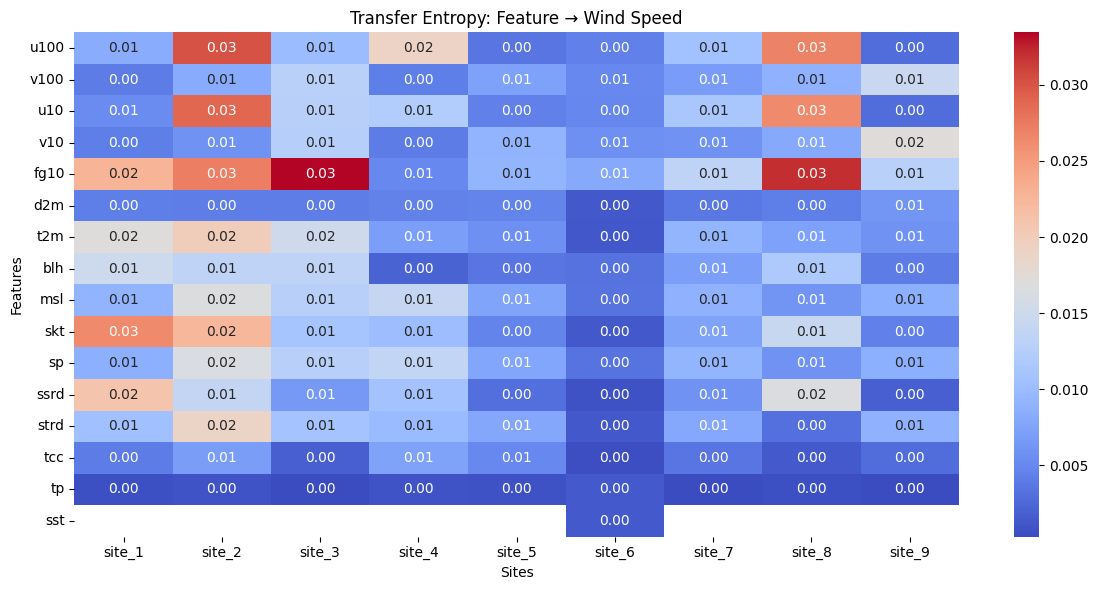

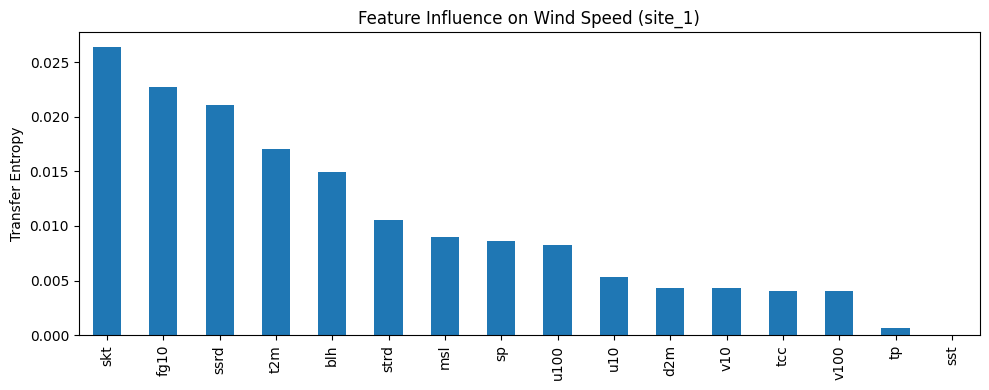

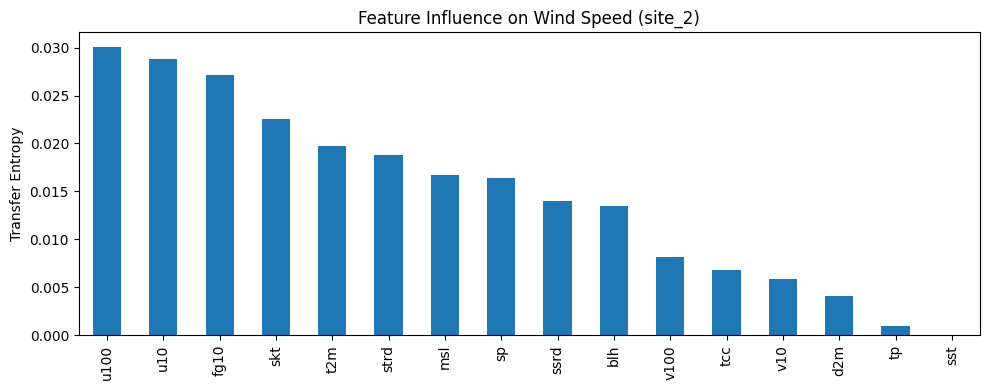

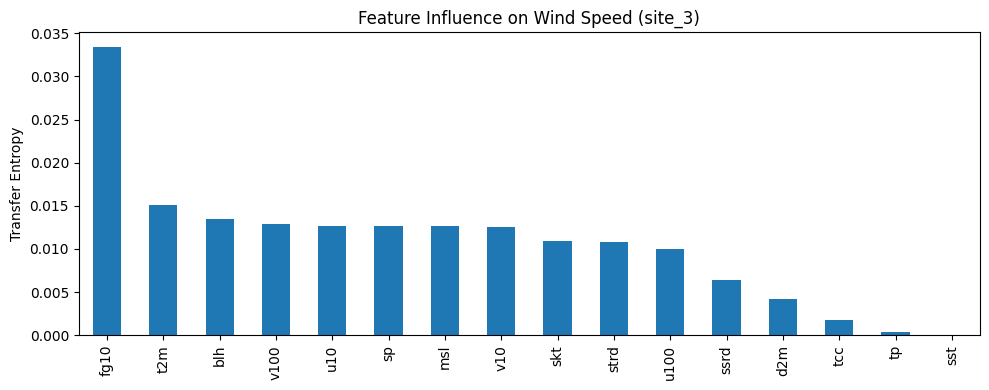

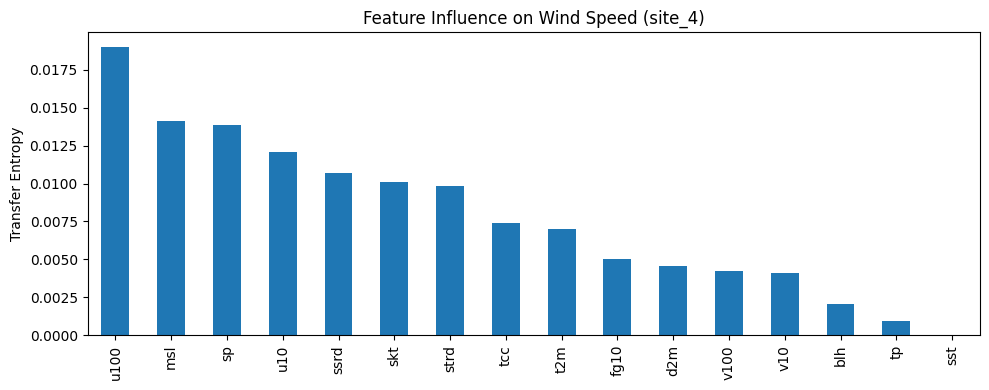

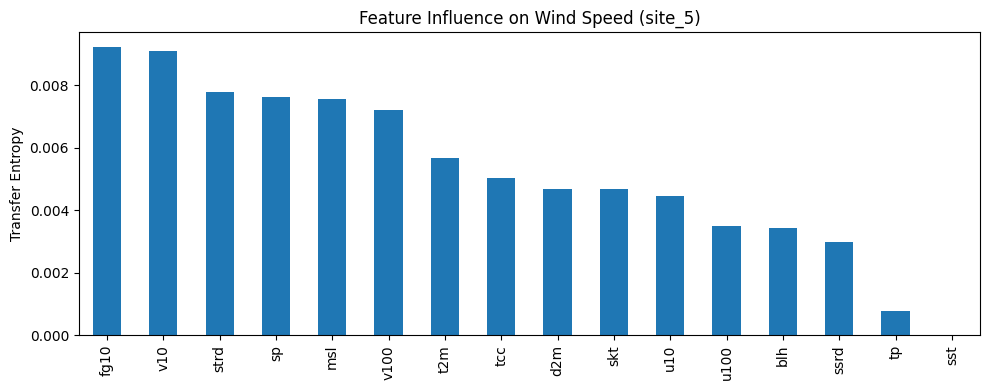

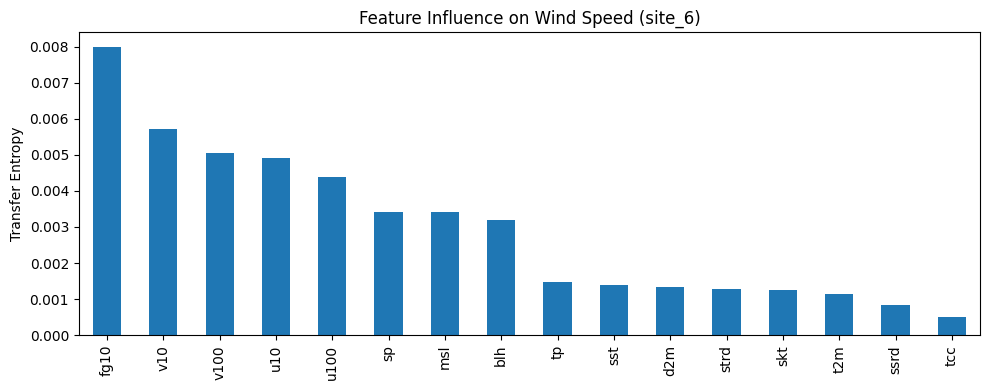

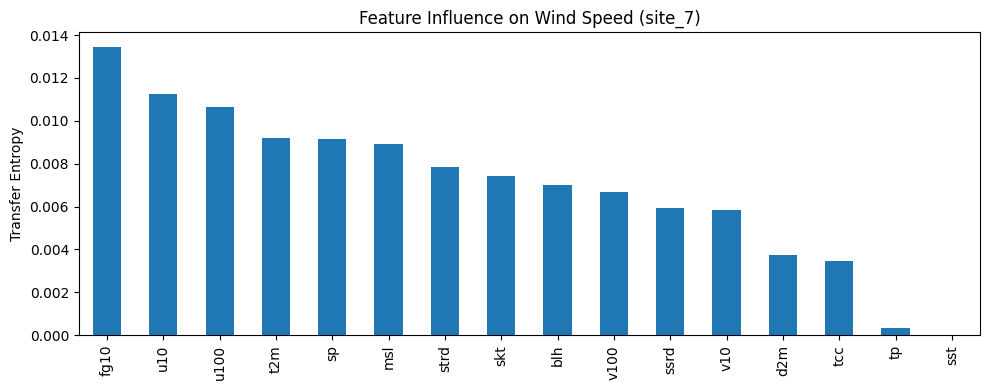

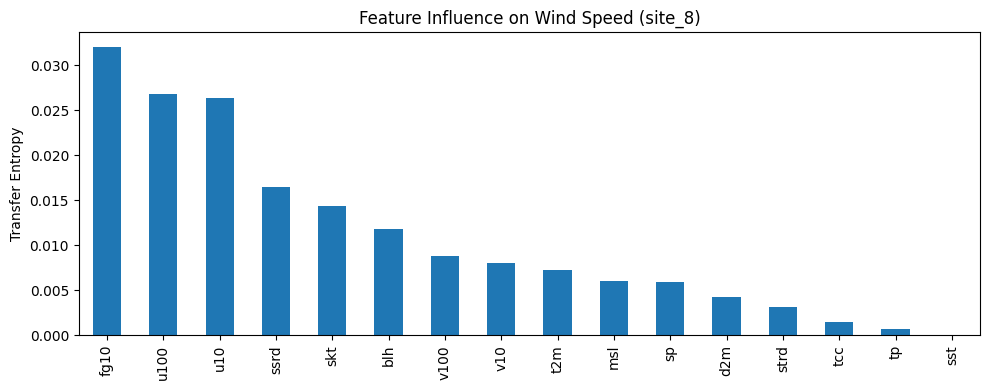

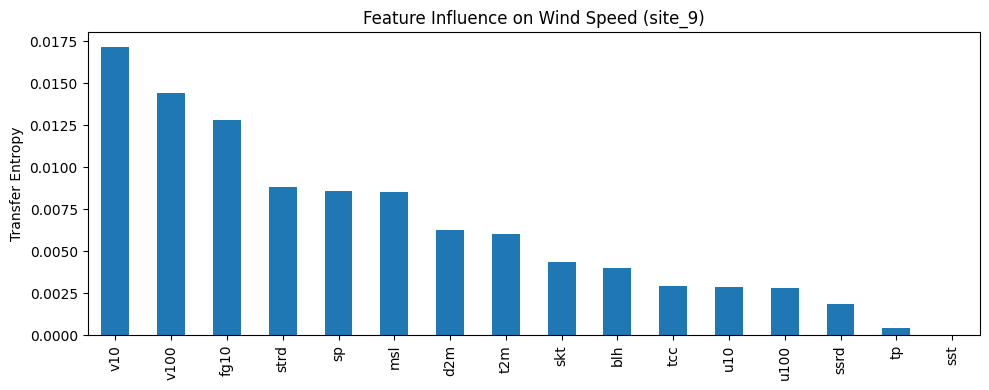


Saved to transfer_entropy_results.csv


In [ ]:
# =========================================
# 0. IMPORTS
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyinform.transferentropy import transfer_entropy
from sklearn.preprocessing import StandardScaler


# =========================================
# 1. DROP NON-NUMERIC / USELESS COLUMNS
# =========================================
def clean_site(site_df):
    site = site_df.copy()

    # Drop non-useful columns
    drop_cols = ["valid_time", "latitude", "longitude"]
    site = site.drop(columns=[c for c in drop_cols if c in site.columns])

    # Drop NA if any
    site = site.dropna()

    return site


# =========================================
# 2. DISCRETIZATION
# =========================================
def discretize(series, bins=5):
    hist, bin_edges = np.histogram(series, bins=bins)
    return np.digitize(series, bin_edges[:-1])


# =========================================
# 3. TRANSFER ENTROPY FOR ONE SITE
# =========================================
def compute_te_for_site(site_df, target_col="wind_speed", bins=5, k=1):

    site_df = clean_site(site_df)

    # Normalize
    scaler = StandardScaler()
    site_scaled = pd.DataFrame(
        scaler.fit_transform(site_df),
        columns=site_df.columns
    )

    results = {}

    target = discretize(site_scaled[target_col].values, bins=bins)

    for col in site_scaled.columns:
        if col == target_col:
            continue

        try:
            feature = discretize(site_scaled[col].values, bins=bins)

            # Lagged TE: feature(t-1) → wind(t)
            te = transfer_entropy(feature[:-1], target[1:], k=k)

            results[col] = te

        except Exception as e:
            results[col] = np.nan

    return results


# =========================================
# 4. APPLY TO ALL SITES
# =========================================
sites = [
    site1, site2, site3, site4, site5,
    site6, site7, site8, site9
]

all_results = {}

for i, site in enumerate(sites):
    print(f"Processing site_{i+1}...")

    res = compute_te_for_site(site)
    all_results[f"site_{i+1}"] = res


df_te = pd.DataFrame(all_results)

print("\nTransfer Entropy Results:")
print(df_te)


# =========================================
# 5. HEATMAP VISUALIZATION
# =========================================
plt.figure(figsize=(12, 6))

sns.heatmap(
    df_te,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Transfer Entropy: Feature → Wind Speed")
plt.ylabel("Features")
plt.xlabel("Sites")

plt.tight_layout()
plt.show()


# =========================================
# 6. BAR PLOTS PER SITE
# =========================================
for site_name in df_te.columns:

    plt.figure(figsize=(10, 4))

    df_te[site_name].sort_values(ascending=False).plot(kind="bar")

    plt.title(f"Feature Influence on Wind Speed ({site_name})")
    plt.ylabel("Transfer Entropy")

    plt.tight_layout()
    plt.show()


# =========================================
# 7. SAVE OUTPUT
# =========================================
df_te.to_csv("transfer_entropy_results.csv")

print("\nSaved to transfer_entropy_results.csv")

In [ ]:
# # Create a combined dataframe with wind_speed from each site
# df_ws = pd.DataFrame()

# for i, site in enumerate([site1, site2, site3, site4, site5, site6, site7, site8, site9]):
#     temp = site.copy()
#     temp["valid_time"] = pd.to_datetime(temp["valid_time"])
#     temp = temp.sort_values("valid_time")

#     df_ws[f"site_{i+1}"] = temp.set_index("valid_time")["wind_speed"]

# corr_ws = df_ws.corr()

# print(corr_ws)

In [ ]:


# =========================
# STEP 1: Combine wind speed
# =========================
df_ws = pd.DataFrame()

sites = [site1, site2, site3, site4, site5, site6, site7, site8, site9]

for i, site in enumerate(sites):
    temp = site.copy()

    temp["valid_time"] = pd.to_datetime(temp["valid_time"])
    temp = temp.sort_values("valid_time")
    temp = temp.set_index("valid_time")

    df_ws[f"site_{i+1}"] = temp["wind_speed"]

# Align + clean
df_ws = df_ws.sort_index()
df_ws = df_ws.dropna()

# =========================
# STEP 2: Filter January 2020
# =========================
jan_2020 = df_ws.loc["2020-01-01":"2020-01-31"]

print("Jan 2020 shape:", jan_2020.shape)

# =========================
# STEP 3: Rolling correlation
# =========================
window = 24   # 24-hour window

rolling_corr = pd.DataFrame(index=jan_2020.index)

for col in jan_2020.columns:
    if col != "site_1":
        rolling_corr[col] = jan_2020["site_1"].rolling(window).corr(jan_2020[col])

# Optional smoothing
rolling_corr = rolling_corr.rolling(3).mean()



Jan 2020 shape: (744, 9)


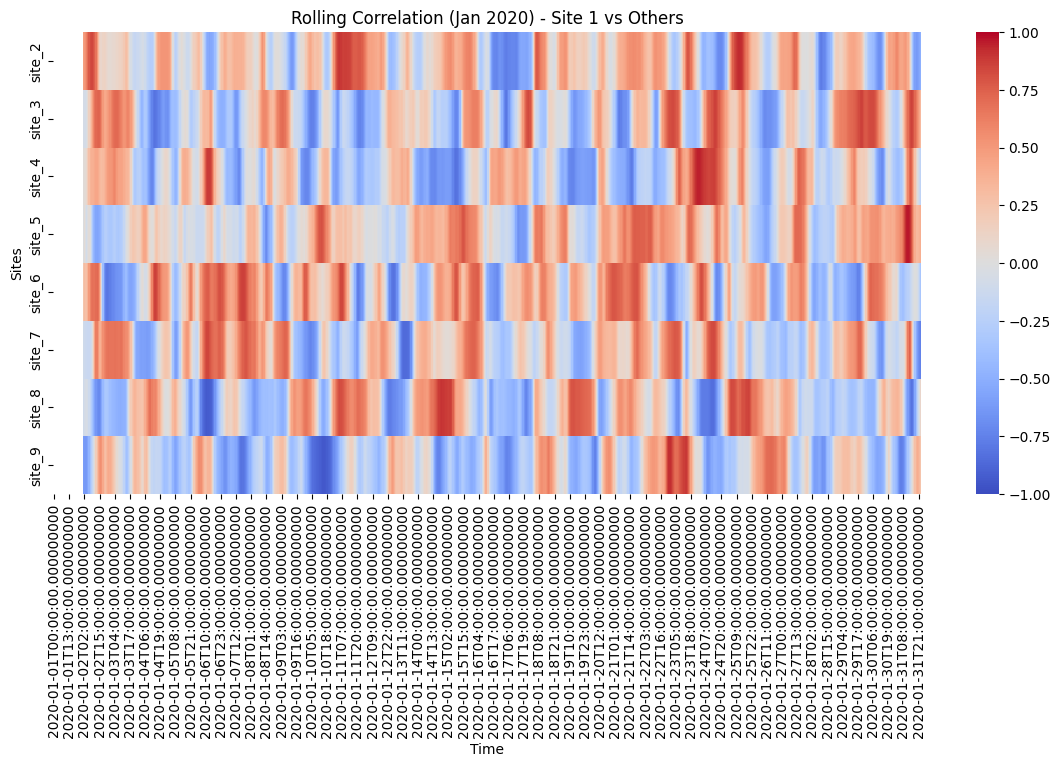

In [ ]:
plt.figure(figsize=(14,6))

sns.heatmap(
    rolling_corr.T,   # transpose → sites on y-axis
    cmap="coolwarm",
    vmin=-1, vmax=1
)

plt.title("Rolling Correlation (Jan 2020) - Site 1 vs Others")
plt.xlabel("Time")
plt.ylabel("Sites")

plt.show()

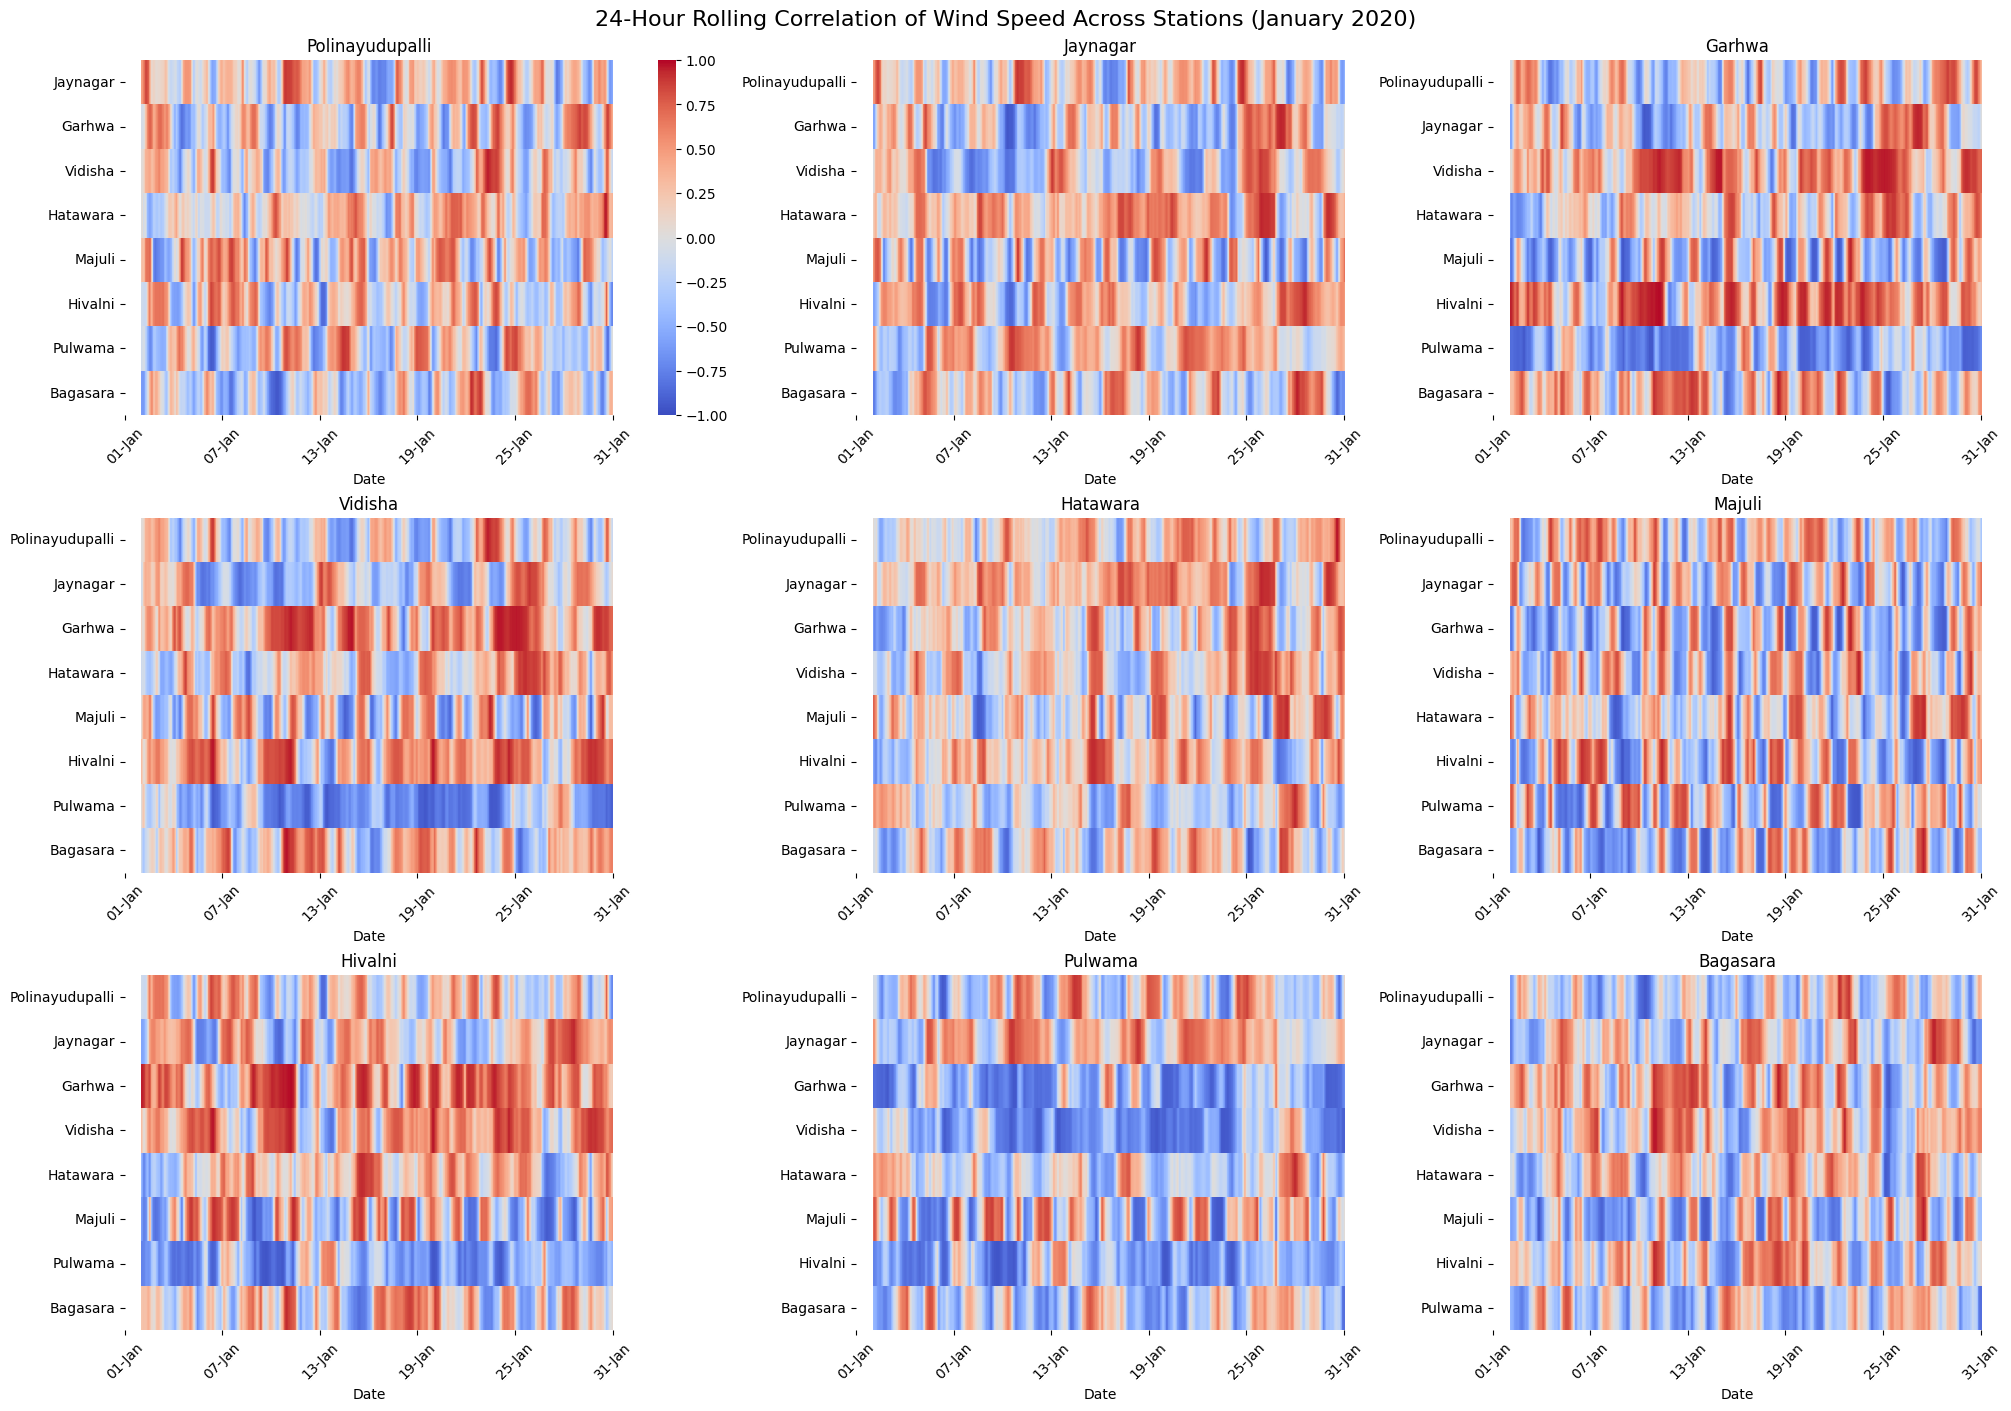

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# =========================
# STEP 1: Combine wind speed
# =========================
df_ws = pd.DataFrame()

sites = [site1, site2, site3, site4, site5, site6, site7, site8, site9]
site_names = [
    "Polinayudupalli",
    "Jaynagar",
    "Garhwa",
    "Vidisha",
    "Hatawara",
    "Majuli",
    "Hivalni",
    "Pulwama",
    "Bagasara"
]

for i, site in enumerate(sites):
    temp = site.copy()
    temp["valid_time"] = pd.to_datetime(temp["valid_time"])
    temp = temp.sort_values("valid_time")
    temp = temp.set_index("valid_time")

    df_ws[site_names[i]] = temp["wind_speed"]

# Align data
df_ws = df_ws.sort_index().dropna()

# =========================
# STEP 2: January 2020
# =========================
jan_2020 = df_ws.loc["2020-01-01":"2020-01-31"]

# =========================
# STEP 3: Rolling correlation
# =========================
window = 24  # 24-hour rolling

rolling_results = {}

for ref_site in jan_2020.columns:

    corr_df = pd.DataFrame(index=jan_2020.index)

    for target_site in jan_2020.columns:
        if ref_site != target_site:
            corr_df[target_site] = (
                jan_2020[ref_site]
                .rolling(window)
                .corr(jan_2020[target_site])
            )

    # smooth
    corr_df = corr_df.rolling(3).mean()

    rolling_results[ref_site] = corr_df

# =========================
# STEP 4: Plot all sites
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(20, 14),
    constrained_layout=True
)

axes = axes.flatten()

for idx, ref_site in enumerate(site_names):

    sns.heatmap(
        rolling_results[ref_site].T,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        ax=axes[idx],
        cbar=(idx == 0)
    )

    axes[idx].set_title(f"{ref_site}")
    axes[idx].set_xlabel("Date")
    axes[idx].set_ylabel("")

    # Show only dates on x-axis
    xticks = np.linspace(
        0,
        len(rolling_results[ref_site].index)-1,
        6,
        dtype=int
    )

    axes[idx].set_xticks(xticks)
    axes[idx].set_xticklabels(
        rolling_results[ref_site].index[xticks].strftime("%d-%b"),
        rotation=45
    )

plt.suptitle(
    "24-Hour Rolling Correlation of Wind Speed Across Stations (January 2020)",
    fontsize=16
)

plt.show()

In [ ]:
# import torch
# import pandas as pd

# # df_ws already prepared (744 × 9)

# # convert to tensor
# data_tensor = torch.tensor(df_ws.values, dtype=torch.float32)

# num_nodes = data_tensor.shape[1]   # 9 sites

# import torch.nn as nn
# from torch_geometric.nn import GATConv

# class GATModel(nn.Module):
#     def __init__(self, in_channels, hidden_channels):
#         super().__init__()

#         self.gat = GATConv(
#             in_channels=in_channels,
#             out_channels=hidden_channels,
#             heads=1,
#             concat=False
#         )

#     def forward(self, x, edge_index):
#         out, (edge_idx, attn_weights) = self.gat(
#             x, edge_index, return_attention_weights=True
#         )
#         return out, attn_weights

# # fully connected graph
# edge_index = []

# for i in range(num_nodes):
#     for j in range(num_nodes):
#         edge_index.append([i, j])

# edge_index = torch.tensor(edge_index, dtype=torch.long).T
# model = GATModel(in_channels=1, hidden_channels=8)
# attention_list = []

# for t in range(data_tensor.shape[0]):

#     # node features at time t → shape (nodes, features)
#     x = data_tensor[t].unsqueeze(1)   # (9, 1)

#     out, attn = model(x, edge_index)

#     # attn shape: (num_edges,)
#     attention_list.append(attn.detach().numpy())
#     import numpy as np

# A_dynamic = []

# for attn in attention_list:
#     A = np.zeros((num_nodes, num_nodes))

#     for idx, (i, j) in enumerate(edge_index.T.numpy()):
#         A[i, j] = attn[idx]

#     A_dynamic.append(A)
# import seaborn as sns
# import matplotlib.pyplot as plt

# t = 10  # any hour

# plt.figure(figsize=(6,5))
# sns.heatmap(A_dynamic[t], cmap="coolwarm")

# plt.title(f"Attention (Importance) at time {t}")
# plt.xlabel("Influencing site")
# plt.ylabel("Target site")
# plt.show()
# site_names = df_ws.columns

# t = 100
# A = A_dynamic[t]

# indices = np.unravel_index(np.argsort(A, axis=None)[-10:], A.shape)

# print(f"\nTop influences at time {t}:")

# for i, j in zip(indices[0], indices[1]):
#     print(f"{site_names[j]} → {site_names[i]}: {A[i,j]:.3f}")
# for t in range(len(A_dynamic)):
#     A = A_dynamic[t]

#     indices = np.unravel_index(
#         np.argsort(A, axis=None)[-5:],   # top 5 only (cleaner)
#         A.shape
#     )

#     for i, j in zip(indices[0], indices[1]):
#         records.append({
#             "time": t,
#             "target": site_names[i],
#             "source": site_names[j],
#             "importance": A[i, j]
#         })

# import pandas as pd
# df_importance = pd.DataFrame(records)

# print(df_importance.head())
# pivot = df_importance.pivot_table(
#     index="time",
#     columns=["source", "target"],
#     values="importance"
# )

# import seaborn as sns

# plt.figure(figsize=(14,6))
# sns.heatmap(pivot.T, cmap="coolwarm")

# plt.title("Dynamic Influence (All Sites)")
# plt.xlabel("Time")
# plt.ylabel("Source → Target")
# plt.show()

In [ ]:
def create_sliding_window(site_df,
                          input_window=48,
                          output_window=7,
                          stride=3,
                          target_col="wind_speed"):
    """
    Create sliding window dataset with stride

    Parameters:
        input_window : number of past time steps
        output_window : number of future steps
        stride : step size to move window
        target_col : column name

    Returns:
        X : (samples, input_window)
        Y : (samples, output_window)
        df_out : combined dataframe
    """

    # Sort by time if available
    if "valid_time" in site_df.columns:
        site_df = site_df.sort_values("valid_time")

    series = site_df[target_col].values

    X, Y = [], []

    for i in range(0, len(series) - input_window - output_window + 1, stride):

        x = series[i : i + input_window]
        y = series[i + input_window : i + input_window + output_window]

        X.append(x)
        Y.append(y)

    X = np.array(X)
    Y = np.array(Y)

    # Convert to DataFrame
    df_X = pd.DataFrame(X, columns=[f"t-{input_window-i}" for i in range(input_window)])
    df_Y = pd.DataFrame(Y, columns=[f"t+{i+1}" for i in range(output_window)])

    df_out = pd.concat([df_X, df_Y], axis=1)

    return df_out

In [ ]:
site1_sw = create_sliding_window(site1)
site2_sw = create_sliding_window(site2)
site3_sw = create_sliding_window(site3)
site4_sw = create_sliding_window(site4)
site5_sw = create_sliding_window(site5)
site6_sw = create_sliding_window(site6)
site7_sw = create_sliding_window(site7)
site8_sw = create_sliding_window(site8)
site9_sw = create_sliding_window(site9)

NameError: name 'create_sliding_window' is not defined

In [ ]:
import numpy as np
import pandas as pd
from ts2vec import TS2Vec
from sklearn.preprocessing import StandardScaler


def compute_ts2vec_embeddings(site_sw_df,
                              input_window=48,
                              embedding_dim=16,
                              epochs=20):
    """
    Input:
        site_sw_df → sliding window dataframe (first 48 cols = input)

    Output:
        DataFrame with one column: embedding (list)
    """

    # Extract only input part (first 48 columns)
    X = site_sw_df.iloc[:, :input_window].values

    # Normalize (important for TS2Vec)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Reshape → (samples, time, features)
    X = X[:, :, np.newaxis]   # (N, 48, 1)

    # Initialize TS2Vec
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(device)

    model = TS2Vec(
    input_dims=1,
    output_dims=embedding_dim,
    device=device
    )

    # Train
    model.fit(X, n_epochs=epochs)

    # Encode
    embeddings = model.encode(X)   # (N, 48, embedding_dim)

    # Use mean
    embeddings = embeddings.mean(axis=1)

    # Store as list in one column
    df_emb = pd.DataFrame({
        "embedding": [emb.tolist() for emb in embeddings]
    })

    return df_emb

In [ ]:
# site_sw_list = [
#     site1_sw, site2_sw, site3_sw
# ]
site_sw_list = [
    site1_sw, site2_sw, site3_sw, site4_sw, site5_sw,
    site6_sw, site7_sw, site8_sw, site9_sw
]
site_embeddings = {}

for i, site_sw in enumerate(site_sw_list):

    print(f"\nProcessing site_{i+1}...")

    df_emb = compute_ts2vec_embeddings(
        site_sw,
        input_window=48,
        embedding_dim=16,   # hyperparameter
        epochs=1
    )

    print(f"Embeddings shape: {df_emb.shape}")

    site_embeddings[f"site_{i+1}"] = df_emb


Processing site_1...
cpu
Embeddings shape: (18326, 1)

Processing site_2...
cpu
Embeddings shape: (18326, 1)

Processing site_3...
cpu
Embeddings shape: (18326, 1)

Processing site_4...
cpu
Embeddings shape: (18326, 1)

Processing site_5...
cpu
Embeddings shape: (18326, 1)

Processing site_6...
cpu
Embeddings shape: (18326, 1)

Processing site_7...
cpu
Embeddings shape: (18326, 1)

Processing site_8...
cpu
Embeddings shape: (18326, 1)

Processing site_9...
cpu
Embeddings shape: (18326, 1)


In [ ]:
for site_name, df_emb in site_embeddings.items():
    df_emb.to_csv(f"{site_name}_ts2vec_embeddings.csv", index=False)

print("\nAll embeddings saved!")


All embeddings saved!


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def build_dynamic_graph(site_embeddings, temperature=0.5, use_topk=False, top_k=3):
    """
    Improved dynamic graph construction:
    - soft similarity (no hard threshold)
    - temperature scaling
    - optional soft top-k
    - row-normalized adjacency

    Returns:
        A_dynamic → (T, N, N)
    """

    # =========================
    # Extract embeddings
    # =========================
    emb_list = []

    for site, df in site_embeddings.items():
        emb = np.vstack(df["embedding"].values)   # (T, d)
        emb_list.append(emb)

    # (N, T, d)
    emb_array = np.stack(emb_list, axis=0)

    num_sites, T, dim = emb_array.shape

    print(f"Sites: {num_sites}, Time steps: {T}, Emb dim: {dim}")

    # =========================
    # Initialize
    # =========================
    A_dynamic = np.zeros((T, num_sites, num_sites))

    # =========================
    # Build graph over time
    # =========================
    for t in range(T):

        Z_t = emb_array[:, t, :]   # (N, d)

        # ===== cosine similarity =====
        A = cosine_similarity(Z_t)   # (-1 to 1)

        # ===== make positive =====
        A = (A + 1.0) / 2.0   # now (0 to 1)

        # ===== temperature scaling =====
        A = np.exp(A / temperature)

        # ===== optional top-k (soft version) =====
        if use_topk:
            for i in range(num_sites):
                idx = np.argsort(A[i])[:-top_k]
                A[i, idx] = 0

        # ===== add self-loop =====
        np.fill_diagonal(A, 1.0)

        # ===== normalize (CRITICAL) =====
        A = A / (A.sum(axis=1, keepdims=True) + 1e-8)

        A_dynamic[t] = A

    return A_dynamic

In [ ]:
A_dynamic = build_dynamic_graph(
    site_embeddings,
    temperature=0.5,
    use_topk=False   # start WITHOUT sparsity
)

print(A_dynamic.shape)

Sites: 9, Time steps: 18326, Emb dim: 16
(18326, 9, 9)


In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np


# def build_dynamic_graph(site_embeddings, threshold=0.5, top_k=3):
#     """
#     Build dynamic graph (A_t) using:
#     - cosine similarity
#     - threshold filtering
#     - top-k sparsification
#     - safe handling (no NaN)

#     Returns:
#         A_dynamic → (T, N, N)
#     """

#     # =========================
#     # Extract embeddings
#     # =========================
#     emb_list = []

#     for site, df in site_embeddings.items():
#         emb = np.vstack(df["embedding"].values)   # (T, d)
#         emb_list.append(emb)

#     # (N, T, d)
#     emb_array = np.stack(emb_list, axis=0)

#     num_sites, T, dim = emb_array.shape

#     print(f"Sites: {num_sites}, Time steps: {T}, Emb dim: {dim}")

#     # =========================
#     # Initialize
#     # =========================
#     A_dynamic = np.zeros((T, num_sites, num_sites))

#     # =========================
#     # Build graph over time
#     # =========================
#     for t in range(T):

#         Z_t = emb_array[:, t, :]   # (N, d)

#         #  Compute similarity ONCE
#         A = cosine_similarity(Z_t)

#         # =========================
#         #  Remove self loops first
#         # =========================
#         np.fill_diagonal(A, 0)

#         # =========================
#         #  Threshold filtering
#         # =========================
#         if threshold is not None:
#             A[A < threshold] = 0

#         # =========================
#         #  Top-K filtering
#         # =========================
#         if top_k is not None:
#             for i in range(num_sites):
#                 idx = np.argsort(A[i])[:-top_k]
#                 A[i, idx] = 0

#         # =========================
#         #  Handle isolated nodes (CRITICAL FIX)
#         # =========================
#         for i in range(num_sites):
#             if np.sum(A[i]) == 0:
#                 A[i, i] = 1.0   # self-loop fallback

#         # =========================
#         #  Final self-loop stabilization
#         # =========================
#         np.fill_diagonal(A, 1.0)

#         A_dynamic[t] = A

#     return A_dynamic

In [ ]:

# from sklearn.metrics.pairwise import cosine_similarity


# def build_dynamic_graph(site_embeddings, top_k=None):
#     """
#     Build dynamic graph (A_t) from site embeddings

#     Returns:
#         A_dynamic → (T, N, N)
#     """

#     #  Extract embeddings
#     emb_list = []

#     for site, df in site_embeddings.items():
#         emb = np.vstack(df["embedding"].values)   # (T, d)
#         emb_list.append(emb)

#     # Stack → (N_sites, T, d)
#     emb_array = np.stack(emb_list, axis=0)

#     num_sites, T, dim = emb_array.shape

#     print(f"Sites: {num_sites}, Time steps: {T}, Emb dim: {dim}")

#     #  Initialize
#     A_dynamic = np.zeros((T, num_sites, num_sites))

#     #  Build graph at each time
#     for t in range(T):

#         Z_t = emb_array[:, t, :]   # (9, d)

#         A = cosine_similarity(Z_t)

#         # Remove self-loops (optional)
#         np.fill_diagonal(A, 0)

#         # Sparsify (optional)
#         if top_k is not None:
#             for i in range(num_sites):
#                 idx = np.argsort(A[i])[:-top_k]
#                 A[i, idx] = 0

#         A_dynamic[t] = A

#     return A_dynamic

In [ ]:
# # A_dynamic = build_dynamic_graph(site_embeddings, top_k=3)
# A_dynamic = build_dynamic_graph(
#     site_embeddings,
#     threshold=0.0,
#     top_k=3
# )
# A_dynamic.shape

In [ ]:
np.isnan(A_dynamic).sum()

np.int64(0)

In [ ]:
!pip install networkx

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_graph_with_weights(A, title="Graph", threshold=0.0):
    """
    Plot adjacency matrix with cosine similarity as edge labels

    Parameters:
        A : (N x N) adjacency matrix
        threshold : remove weak edges
    """

    G = nx.Graph()
    N = A.shape[0]

    # Add nodes
    for i in range(N):
        G.add_node(i)

    # Add edges with weights
    for i in range(N):
        for j in range(i+1, N):
            if A[i, j] > threshold:
                G.add_edge(i, j, weight=A[i, j])

    # Layout
    pos = nx.spring_layout(G, seed=42)

    # Extract weights
    weights = [G[u][v]['weight'] for u, v in G.edges()]

    plt.figure(figsize=(6,6))

    # Draw graph
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=700,
        font_size=10,
        width=[w * 5 for w in weights]  # scale thickness
    )

    #  Draw edge labels (cosine similarity)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}

    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title(title)
    plt.show()

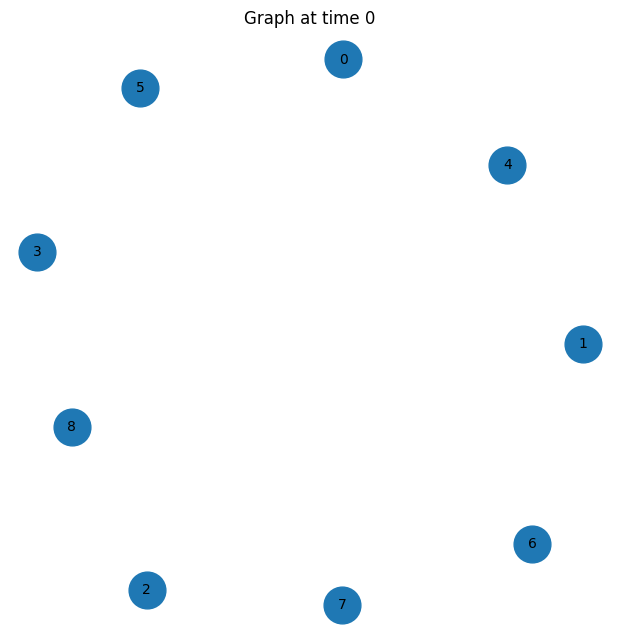

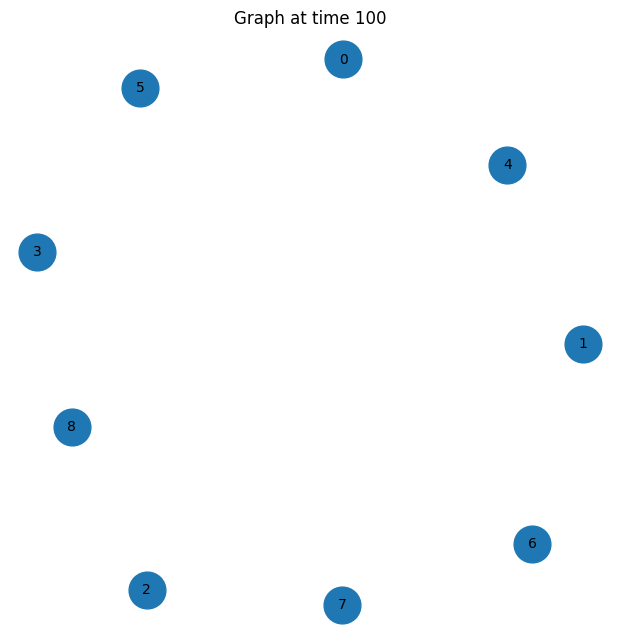

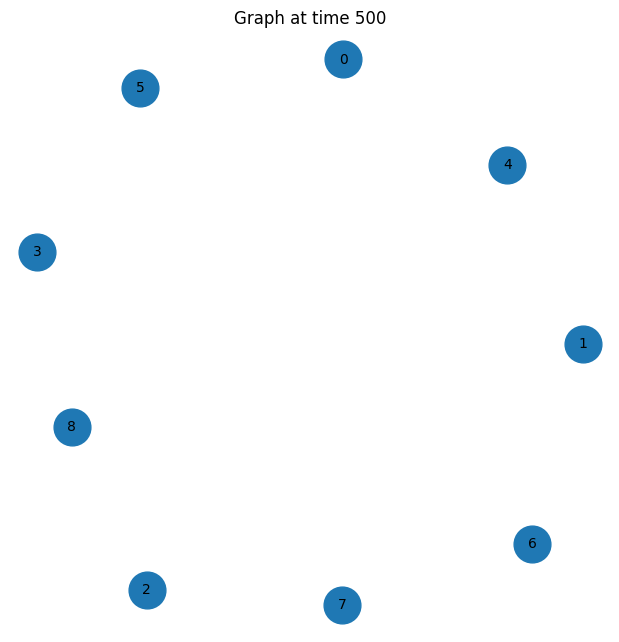

In [ ]:
for t in [0, 100, 500]:
    plot_graph_with_weights(
        A_dynamic[t],
        title=f"Graph at time {t}",
        threshold=0.2
    )

#GAT+LSTM

In [ ]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_embeddings(site_embeddings):
    emb_list = []
    for _, df in site_embeddings.items():
        emb = np.vstack(df["embedding"].values)
        emb_list.append(emb)

    emb_array = np.stack(emb_list, axis=1)  # (T, N, d)
    return torch.tensor(emb_array, dtype=torch.float32)

emb_tensor = prepare_embeddings(site_embeddings)
def prepare_adjacency(A_dynamic):
    return torch.tensor(A_dynamic, dtype=torch.float32)
A_tensor = prepare_adjacency(A_dynamic)

In [ ]:
# =========================
# NORMALIZE WIND DATA
# =========================
def normalize_sites(site_sw_list):
    normalized = []
    stats = []

    for df in site_sw_list:
        values = df.values.astype(float)

        mean = values.mean()
        std = values.std() + 1e-8

        norm_values = (values - mean) / std

        # keep same structure
        norm_df = df.copy()
        norm_df.iloc[:, :] = norm_values

        normalized.append(norm_df)
        stats.append((mean, std))

    return normalized, stats


site_sw_list, wind_stats = normalize_sites(site_sw_list)

In [ ]:
# =========================
# NORMALIZE EMBEDDINGS
# =========================
emb_tensor = (emb_tensor - emb_tensor.mean()) / (emb_tensor.std() + 1e-8)

In [ ]:
import torch
import numpy as np

class WindDataset(torch.utils.data.Dataset):

    def __init__(self, site_sw_list, emb_tensor, A_tensor, window=48, horizon=7):

        self.window = window
        self.horizon = horizon

        # =========================
        # Embeddings & Graph
        # =========================
        self.X = torch.tensor(emb_tensor, dtype=torch.float32)
        self.A = torch.tensor(A_tensor, dtype=torch.float32)

        # =========================
        # Wind data (T, N)
        # =========================
        wind_np = np.stack(
            [df.iloc[:, 0].values for df in site_sw_list], axis=1
        )

        # =========================
        # 🔥 NORMALIZATION (CRITICAL)
        # =========================
        self.wind_mean = wind_np.mean(axis=0, keepdims=True)
        self.wind_std  = wind_np.std(axis=0, keepdims=True) + 1e-8

        wind_np = (wind_np - self.wind_mean) / self.wind_std

        self.wind_data = torch.tensor(wind_np, dtype=torch.float32)

        # =========================
        # Meta
        # =========================
        self.num_sites = self.wind_data.shape[1]

        self.time_length = len(self.X) - window - horizon
        self.length = self.time_length * self.num_sites

    def __len__(self):
        return self.length

    def __getitem__(self, idx):

        # =========================
        # Map index → (time, site)
        # =========================
        time_idx = idx // self.num_sites
        site_idx = idx % self.num_sites

        # =========================
        # Inputs
        # =========================
        emb_seq = self.X[time_idx:time_idx + self.window]      # (W, N, d)
        A_seq   = self.A[time_idx:time_idx + self.window]      # (W, N, N)
        wind_seq = self.wind_data[time_idx:time_idx + self.window]  # (W, N)

        # =========================
        # Target (ONE site)
        # =========================
        target = self.wind_data[
            time_idx + self.window : time_idx + self.window + self.horizon,
            site_idx
        ]  # (H,)

        # =========================
        # 🔥 BASELINE (IMPORTANT)
        # =========================
        last_value = wind_seq[-1, site_idx]  # scalar

        return (
            emb_seq,
            A_seq,
            wind_seq,
            target,
            site_idx,
            last_value   # 🔥 helps residual learning
        )

In [ ]:
import torch

# =========================
# DATASET
# =========================
dataset = WindDataset(site_sw_list, emb_tensor, A_dynamic)

num_sites = dataset.num_sites
time_length = dataset.time_length

# =========================
# TIME-BASED SPLIT
# =========================
train_time = int(0.7 * time_length)
val_time   = int(0.15 * time_length)

# =========================
# Convert time → indices
# =========================
def time_to_indices(start_t, end_t):
    indices = []
    for t in range(start_t, end_t):
        for s in range(num_sites):
            indices.append(t * num_sites + s)
    return indices

train_indices = time_to_indices(0, train_time)
val_indices   = time_to_indices(train_time, train_time + val_time)
test_indices  = time_to_indices(train_time + val_time, time_length)

# =========================
# DATASETS
# =========================
train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset   = torch.utils.data.Subset(dataset, val_indices)
test_dataset  = torch.utils.data.Subset(dataset, test_indices)

# =========================
# LOADERS (FINAL)
# =========================
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False,          # 🔥 IMPORTANT
    drop_last=True,        # 🔥 stable batches
    pin_memory=True,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

/tmp/ipykernel_6515/1572810147.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(emb_tensor, dtype=torch.float32)


In [ ]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

NameError: name 'train_dataset' is not defined

In [ ]:
# import torch
# import numpy as np

# class WindDataset(torch.utils.data.Dataset):

#     def __init__(self, site_sw_list, emb_tensor, A_tensor, window=48, horizon=7):
#         self.site_sw = site_sw_list
#         self.X = emb_tensor      # (T, N, d)
#         self.A = A_tensor        # (T, N, N)
#         self.window = window
#         self.horizon = horizon

#     def __len__(self):
#         return len(self.X) - self.window - self.horizon

#     def __getitem__(self, idx):

#         # ===== Embeddings & Graph =====
#         emb_seq = self.X[idx:idx+self.window]   # (W, N, d)
#         A_seq   = self.A[idx:idx+self.window]   # (W, N, N)

#         # ===== Wind (ALL sites, temporal) =====
#         wind_seq = []

#         for site_df in self.site_sw:
#             wind = site_df.iloc[idx:idx+self.window, 0].values  # (W,)
#             wind_seq.append(wind)

#         wind_seq = np.stack(wind_seq, axis=1)  # (W, N)

#         # ===== Target (site 0) =====
#         target = self.site_sw[0].iloc[
#             idx + self.window : idx + self.window + self.horizon, 0
#         ].values

#         return (
#             torch.tensor(emb_seq, dtype=torch.float32),
#             torch.tensor(A_seq, dtype=torch.float32),
#             torch.tensor(wind_seq, dtype=torch.float32),
#             torch.tensor(target, dtype=torch.float32)
#         )

In [ ]:
# import torch
# import numpy as np

# class WindDataset(torch.utils.data.Dataset):

#     def __init__(self, site_sw_list, emb_tensor, A_tensor, window=48, horizon=7):
#         self.site_sw = site_sw_list
#         self.X = emb_tensor      # (T, N, d)
#         self.A = A_tensor        # (T, N, N)
#         self.window = window
#         self.horizon = horizon

#     def __len__(self):
#         return len(self.X) - self.window - self.horizon

#     def __getitem__(self, idx):

#         # ===== Embedding & Graph =====
#         emb_seq = self.X[idx:idx+self.window]   # (W, N, d)
#         A_seq   = self.A[idx:idx+self.window]   # (W, N, N)

#         # ===== Wind (ALL SITES, TEMPORAL) =====
#         wind_seq = []

#         for site_df in self.site_sw:
#             wind = site_df.iloc[idx:idx+self.window, 0].values  # (W,)
#             wind_seq.append(wind)

#         wind_seq = np.stack(wind_seq, axis=1)  # (W, N)

#         # ===== Target (choose site 0) =====
#         target = self.site_sw[0].iloc[
#             idx + self.window : idx + self.window + self.horizon, 0
#         ].values  # (7,)

#         return (
#             torch.tensor(emb_seq, dtype=torch.float32),
#             torch.tensor(A_seq, dtype=torch.float32),
#             torch.tensor(wind_seq, dtype=torch.float32),
#             torch.tensor(target, dtype=torch.float32)
#         )

In [ ]:
# import torch
# import numpy as np

# class WindDataset(torch.utils.data.Dataset):

#     def __init__(self, site_sw_list, emb_tensor, A_tensor, window=48, horizon=7):
#         self.site_sw = site_sw_list
#         self.X = emb_tensor          # (T, N, d)
#         self.A = A_tensor            # (T, N, N)
#         self.window = window
#         self.horizon = horizon

#     def __len__(self):
#         return len(self.X) - self.window - self.horizon

#     def __getitem__(self, idx):

#         # =========================
#         # Embedding & Graph (correct)
#         # =========================
#         emb_seq = self.X[idx:idx+self.window]   # (W, N, d)
#         A_seq   = self.A[idx:idx+self.window]   # (W, N, N)

#         # =========================
#         # Wind (FIXED)
#         # =========================
#         wind_seq = []

#         for site_df in self.site_sw:
#             # take TIME window, not columns
#             wind = site_df.iloc[idx:idx+self.window, 0].values  # assuming 1 feature
#             wind_seq.append(wind)

#         wind_seq = np.stack(wind_seq, axis=1)  # (W, N)

#         # =========================
#         # Target (FIXED)
#         # =========================
#         target = self.site_sw[0].iloc[
#             idx + self.window : idx + self.window + self.horizon, 0
#         ].values   # (7,)

#         return (
#             torch.tensor(emb_seq, dtype=torch.float32),
#             torch.tensor(A_seq, dtype=torch.float32),
#             torch.tensor(wind_seq, dtype=torch.float32),
#             torch.tensor(target, dtype=torch.float32)
#         )

In [ ]:
# class WindDataset(torch.utils.data.Dataset):

#     def __init__(self, site_sw_list, emb_tensor, A_tensor, window=48):
#         self.site_sw = site_sw_list
#         self.X = emb_tensor
#         self.A = A_tensor
#         self.window = window

#     def __len__(self):
#         return len(self.site_sw[0]) - self.window - 1

#     def __getitem__(self, idx):

#         emb_seq = self.X[idx:idx+self.window]      # (W, N, d)
#         A_seq = self.A[idx:idx+self.window]        # (W, N, N)

#         wind_seq = []
#         for site_df in self.site_sw:
#             wind_seq.append(site_df.iloc[idx, :48].values)

#         wind_seq = np.stack(wind_seq, axis=0)  # (N, 48)

#         target = self.site_sw[0].iloc[idx, 48:55].values

#         return (
#             emb_seq,
#             A_seq,
#             torch.tensor(wind_seq, dtype=torch.float32),
#             torch.tensor(target, dtype=torch.float32)
#         )

In [ ]:
from torch_geometric.nn import GATConv
import torch.nn as nn
import torch.nn.functional as F

class GATGraph(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.gat1 = GATConv(in_dim, in_dim, heads=1, concat=False)
        self.gat2 = GATConv(in_dim, in_dim, heads=1, concat=False)

    def forward(self, x, edge_index):

        x = F.relu(self.gat1(x, edge_index))
        x = self.gat2(x, edge_index)

        return x

In [ ]:
def adj_to_edge_index(A):
    return torch.nonzero(A, as_tuple=False).T

In [ ]:
class DenseGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim=None):
        super().__init__()

        hidden_dim = in_dim if hidden_dim is None else hidden_dim

        self.W = nn.Linear(in_dim, hidden_dim)
        self.attn = nn.Linear(2 * hidden_dim, 1)

    def forward(self, x, A):
        """
        x: (B*W, N, d)
        A: (B*W, N, N)
        """

        h = self.W(x)   # (B*W, N, d)

        BWN, N, d = h.shape

        # pairwise combinations
        h_i = h.unsqueeze(2).expand(-1, -1, N, -1)
        h_j = h.unsqueeze(1).expand(-1, N, -1, -1)

        a_input = torch.cat([h_i, h_j], dim=-1)   # (B*W, N, N, 2d)

        e = self.attn(a_input).squeeze(-1)        # (B*W, N, N)

        # mask using adjacency
        e = e.masked_fill(A == 0, -1e4)

        alpha = torch.softmax(e, dim=-1)

        h_out = torch.matmul(alpha, h)            # (B*W, N, d)

        return h_out

In [ ]:
# class GAT_LSTM_Model(nn.Module):

#     def __init__(self, in_dim=16, num_nodes=9, lstm_hidden=64):
#         super().__init__()

#         self.num_nodes = num_nodes
#         self.in_dim = in_dim

#         #  DENSE GAT
#         self.gat = DenseGAT(in_dim)

#         self.input_dim = in_dim + num_nodes * 48

#         self.lstm = nn.LSTM(
#           input_size=self.input_dim,
#           hidden_size=lstm_hidden,
#           num_layers=2,
#           batch_first=True,
#           dropout=0.1
#           )

#         self.relu = nn.Tanh()        # ADD THIS
#         # self.dropout = nn.Dropout(0.1)

#         self.fc = nn.Linear(lstm_hidden, 7)

#     def forward(self, emb_seq, A_seq, wind_seq):

#         B, W, N, d = emb_seq.shape

#         #  flatten everything
#         x = emb_seq.reshape(B * W, N, d)
#         A = A_seq.reshape(B * W, N, N)

#         #  ONE SHOT GAT (NO LOOP)
#         x_out = self.gat(x, A)   # (B*W, N, d)

#         #  graph feature
#         g_feat = x_out.mean(dim=1)   # (B*W, d)

#         # reshape back
#         g_feat = g_feat.view(B, W, d)

#         # wind
#         wind_flat = wind_seq.reshape(B, -1)
#         wind_rep = wind_flat.unsqueeze(1).repeat(1, W, 1)

#         combined = torch.cat([g_feat, wind_rep], dim=2)

#         # LSTM
#         out, _ = self.lstm(combined)

#         out = self.fc(out[:, -1, :])

#         return out

In [ ]:
# from torch.utils.data import random_split

# # create dataset
# dataset = WindDataset(site_sw_list, emb_tensor, A_tensor)

# # sizes
# total_size = len(dataset)

# train_size = int(0.7 * total_size)
# val_size   = int(0.15 * total_size)
# test_size  = total_size - train_size - val_size

# # split
# train_dataset, val_dataset, test_dataset = random_split(
#     dataset,
#     [train_size, val_size, test_size]
# )

# print(len(train_dataset), len(val_dataset), len(test_dataset))

In [ ]:
# train_loader = torch.utils.data.DataLoader(
#     train_dataset,
#     batch_size=32,
#     shuffle=False,
#     num_workers=0,        # MUST
#     pin_memory=False      # change this too
# )

# val_loader = torch.utils.data.DataLoader(
#     val_dataset,
#     batch_size=32,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=False
# )

# test_loader = torch.utils.data.DataLoader(
#     test_dataset,
#     batch_size=32,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=False
# )

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# =========================
# DENSE GAT
# =========================
class DenseGAT(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.W = nn.Linear(in_dim, in_dim, bias=False)
        self.a = nn.Linear(2 * in_dim, 1, bias=False)
        self.leakyrelu = nn.LeakyReLU(0.2)

    def forward(self, x, A):

        Wh = self.W(x)
        N = Wh.size(1)

        Wh_i = Wh.unsqueeze(2).repeat(1, 1, N, 1)
        Wh_j = Wh.unsqueeze(1).repeat(1, N, 1, 1)

        e = self.a(torch.cat([Wh_i, Wh_j], dim=-1)).squeeze(-1)
        e = self.leakyrelu(e)

        # safer masking
        e = e.masked_fill(A == 0, -1e4)

        attention = torch.softmax(e, dim=-1)
        attention = torch.nan_to_num(attention)  # 🔥 stability

        out = torch.matmul(attention, Wh)

        return out, attention


# =========================
# GAT BLOCK
# =========================
class GATBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()

        self.gat = DenseGAT(in_dim)
        self.lin = nn.Linear(in_dim, out_dim)

        self.res_proj = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

        self.norm = nn.LayerNorm(out_dim)
        self.relu = nn.ReLU()

    def forward(self, x, A):

        h, attn = self.gat(x, A)

        h_res = self.res_proj(h)

        h = self.lin(h)
        h = h + h_res

        h = self.relu(h)
        h = self.norm(h)

        return h, attn


# =========================
# FINAL MODEL
# =========================
class GAT_LSTM_Model(nn.Module):
    def __init__(self, emb_dim=16, num_sites=9, lstm_hidden=64):
        super().__init__()

        self.num_sites = num_sites
        self.input_dim = emb_dim + 1

        # GAT
        self.gat1 = GATBlock(self.input_dim, 64)
        self.gat2 = GATBlock(64, 64)

        self.readout = nn.Linear(64, 64)

        #  LEARNABLE GRAPH
        self.node_emb = nn.Parameter(torch.randn(num_sites, 16))
        self.graph_alpha = nn.Parameter(torch.tensor(0.5))

        # LSTM
        self.lstm = nn.LSTM(
            input_size=64 * num_sites,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        # FC
        self.fc = nn.Linear(2 * lstm_hidden + num_sites, 7)

        self.last_attn = None

    def forward(self, emb_seq, A_seq, wind_seq, site_idx, last_value=None):

        B, T, N, d = emb_seq.shape

        # ===== combine wind + embedding =====
        wind_seq = wind_seq.unsqueeze(-1)
        x = torch.cat([emb_seq, wind_seq], dim=-1)

        # ===== reshape =====
        x = x.reshape(B * T, N, d + 1)

        # ===== dynamic graph =====
        A_dyn = A_seq.reshape(B * T, N, N)

        # ===== learned graph =====
        E = self.node_emb
        A_learned = torch.softmax(E @ E.T, dim=-1)
        A_learned = A_learned.unsqueeze(0).expand(B * T, -1, -1)

        # ===== combine graphs =====
        alpha = torch.sigmoid(self.graph_alpha)
        A = alpha * A_dyn + (1 - alpha) * A_learned

        # ===== GAT =====
        h, attn = self.gat1(x, A)
        h, _ = self.gat2(h, A)

        self.last_attn = attn

        # ===== restore =====
        h = h.view(B, T, N, 64)

        g_feat = self.readout(h)
        g_feat = g_feat.view(B, T, N * 64)

        # ===== LSTM =====
        out, _ = self.lstm(g_feat)

        out = self.dropout(out[:, -1, :])

        # ===== site conditioning =====
        site_onehot = F.one_hot(site_idx, num_classes=self.num_sites).float().to(out.device)
        out = torch.cat([out, site_onehot], dim=1)

        # ===== final =====
        out = self.fc(out)

        #  RESIDUAL BASELINE (IMPORTANT)
        if last_value is not None:
            baseline = last_value.unsqueeze(1).repeat(1, 7)
            out = out + baseline

        return out

In [ ]:
# import torch
# import torch.nn as nn
# import matplotlib.pyplot as plt
# from torch.amp import autocast, GradScaler

# # =========================
# # DEVICE
# # =========================
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # =========================
# # MODEL
# # =========================
# model = GAT_LSTM_Model(in_dim=16).to(device)

# # =========================
# # OPTIMIZER & LOSS
# # =========================
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# loss_fn = nn.MSELoss()

# # =========================
# # LR SCHEDULER (IMPORTANT)
# # =========================
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', patience=2, factor=0.5
# )

# # =========================
# # AMP
# # =========================
# scaler = GradScaler()

# # =========================
# # TRACKING
# # =========================
# train_losses = []
# val_losses = []

# # =========================
# # EARLY STOPPING
# # =========================
# epochs = 30
# best_val_loss = float('inf')
# patience = 5
# counter = 0

# # =========================
# # TRAINING LOOP
# # =========================
# for epoch in range(epochs):

#     # ---------------------
#     # TRAIN
#     # ---------------------
#     model.train()
#     train_loss = 0.0

#     for emb_seq, A_seq, wind_seq, target in train_loader:

#         emb_seq = emb_seq.to(device)
#         A_seq = A_seq.to(device)
#         wind_seq = wind_seq.to(device)
#         target = target.to(device)

#         optimizer.zero_grad()

#         with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
#             pred = model(emb_seq, A_seq, wind_seq)
#             loss = loss_fn(pred, target)

#         scaler.scale(loss).backward()

#         # gradient clipping
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)
#     train_losses.append(train_loss)

#     # ---------------------
#     # VALIDATION
#     # ---------------------
#     model.eval()
#     val_loss = 0.0

#     with torch.no_grad():
#         for emb_seq, A_seq, wind_seq, target in val_loader:

#             emb_seq = emb_seq.to(device)
#             A_seq = A_seq.to(device)
#             wind_seq = wind_seq.to(device)
#             target = target.to(device)

#             with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
#                 pred = model(emb_seq, A_seq, wind_seq)
#                 loss = loss_fn(pred, target)

#             val_loss += loss.item()

#     val_loss /= len(val_loader)
#     val_losses.append(val_loss)

#     print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

#     # ---------------------
#     # LR Scheduler Step
#     # ---------------------
#     scheduler.step(val_loss)

#     # ---------------------
#     # EARLY STOPPING
#     # ---------------------
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0

#         torch.save(model.state_dict(), "best_model.pth")

#     else:
#         counter += 1

#         if counter >= patience:
#             print(f"\n Early stopping at epoch {epoch+1}")
#             break

# # =========================
# # LOAD BEST MODEL
# # =========================
# model.load_state_dict(torch.load("best_model.pth"))

# # =========================
# # PLOT LOSS CURVES
# # =========================
# plt.figure(figsize=(8, 5))

# plt.plot(train_losses, marker='o', label="Train Loss")
# plt.plot(val_losses, marker='s', label="Validation Loss")

# plt.xlabel("Epochs", fontsize=12, fontweight='bold')
# plt.ylabel("Loss", fontsize=12, fontweight='bold')
# plt.title("Training vs Validation Loss", fontsize=14)

# plt.legend()
# plt.grid()

# plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# MODEL
# =========================
model = GAT_LSTM_Model(
    emb_dim=16,
    num_sites=len(site_sw_list)
).to(device)

# =========================
# OPTIMIZER
# =========================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,               #  good default
    weight_decay=1e-5
)

# =========================
# HYBRID LOSS (better than SmoothL1 alone)
# =========================
def hybrid_loss(pred, target):
    l1 = torch.nn.functional.l1_loss(pred, target)
    l2 = torch.nn.functional.mse_loss(pred, target)
    return 0.5 * l1 + 0.5 * l2

# =========================
# LR SCHEDULER
# =========================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

# =========================
# AMP
# =========================
use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

# =========================
# TRAIN SETTINGS
# =========================
epochs = 40
best_val_loss = float('inf')
patience = 5
counter = 0

# =========================
# TRAIN LOOP
# =========================
for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0.0

    for emb_seq, A_seq, wind_seq, target, site_idx, last_value in train_loader:

        emb_seq = emb_seq.to(device)
        A_seq = A_seq.to(device)
        wind_seq = wind_seq.to(device)
        target = target.to(device)
        site_idx = site_idx.to(device)
        last_value = last_value.to(device)

        #  TEMPORARY: disable graph (diagnostic)
        # Remove this line after testing
        A_seq = torch.ones_like(A_seq)

        optimizer.zero_grad()

        with autocast(device_type='cuda', enabled=use_amp):
            pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)
            loss = hybrid_loss(pred, target)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for emb_seq, A_seq, wind_seq, target, site_idx, last_value in val_loader:

            emb_seq = emb_seq.to(device)
            A_seq = A_seq.to(device)
            wind_seq = wind_seq.to(device)
            target = target.to(device)
            site_idx = site_idx.to(device)
            last_value = last_value.to(device)

            #  TEMPORARY: disable graph (diagnostic)
            A_seq = torch.ones_like(A_seq)

            with autocast(device_type='cuda', enabled=use_amp):
                pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)
                loss = hybrid_loss(pred, target)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ===== LR Scheduler =====
    scheduler.step(val_loss)

    # ===== Early Stopping =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(torch.load("best_model.pth"))

Epoch 01 | Train Loss: 0.7659 | Val Loss: 0.7573
Epoch 02 | Train Loss: 0.7563 | Val Loss: 0.7543


In [ ]:
model.eval()

with torch.no_grad():
    for emb_seq, A_seq, wind_seq, target in val_loader:

        emb_seq = emb_seq.to(device)
        A_seq = A_seq.to(device)
        wind_seq = wind_seq.to(device)

        _ = model(emb_seq, A_seq, wind_seq)
        break

attn = model.last_attn   # (B*T, N, N)

import matplotlib.pyplot as plt

attn_sample = attn[0].cpu().numpy()

plt.imshow(attn_sample, cmap='hot')
plt.colorbar()
plt.title("GAT Attention")
plt.show()

In [ ]:
# import torch
# import torch.nn as nn
# import matplotlib.pyplot as plt
# from torch.amp import autocast, GradScaler

# # =========================
# # DEVICE
# # =========================
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # =========================
# # MODEL
# # =========================
# model = GAT_LSTM_Model(in_dim=16).to(device)

# # =========================
# # OPTIMIZER & LOSS
# # =========================
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
# loss_fn = nn.MSELoss()

# # =========================
# # AMP (VERSION SAFE)
# # =========================
# scaler = GradScaler()   # compatible

# # =========================
# # TRACKING
# # =========================
# train_losses = []
# val_losses = []

# # =========================
# # EARLY STOPPING
# # =========================
# epochs = 20
# best_val_loss = float('inf')
# patience = 5
# counter = 0

# # =========================
# # TRAINING LOOP
# # =========================
# for epoch in range(epochs):

#     # ---------------------
#     # TRAIN
#     # ---------------------
#     model.train()
#     train_loss = 0

#     for emb_seq, A_seq, wind_seq, target in train_loader:

#         emb_seq = emb_seq.to(device, non_blocking=True)
#         A_seq = A_seq.to(device, non_blocking=True)
#         wind_seq = wind_seq.to(device, non_blocking=True)
#         target = target.to(device, non_blocking=True)

#         optimizer.zero_grad()

#         #  Mixed precision
#         with autocast('cuda'):
#             pred = model(emb_seq, A_seq, wind_seq)
#             loss = loss_fn(pred, target)

#         scaler.scale(loss).backward()

#         #  Prevent exploding gradients
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)
#     train_losses.append(train_loss)

#     # ---------------------
#     # VALIDATION
#     # ---------------------
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for emb_seq, A_seq, wind_seq, target in val_loader:

#             emb_seq = emb_seq.to(device, non_blocking=True)
#             A_seq = A_seq.to(device, non_blocking=True)
#             wind_seq = wind_seq.to(device, non_blocking=True)
#             target = target.to(device, non_blocking=True)

#             with autocast('cuda'):
#                 pred = model(emb_seq, A_seq, wind_seq)
#                 loss = loss_fn(pred, target)

#             val_loss += loss.item()

#     val_loss /= len(val_loader)
#     val_losses.append(val_loss)

#     print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

#     # ---------------------
#     # EARLY STOPPING
#     # ---------------------
#     if val_loss < best_val_loss - 1e-6:
#         best_val_loss = val_loss
#         counter = 0

#         #  Save best model
#         torch.save(model.state_dict(), "best_model.pth")

#     else:
#         counter += 1

#         if counter >= patience:
#             print(f"\n Early stopping triggered at epoch {epoch+1}")
#             break

# # =========================
# # LOAD BEST MODEL
# # =========================
# model.load_state_dict(torch.load("best_model.pth"))

# # =========================
# # PLOT LOSS CURVES
# # =========================
# plt.figure(figsize=(8,5))

# plt.plot(train_losses, marker='o', label="Train Loss")
# plt.plot(val_losses, marker='s', label="Validation Loss")

# plt.xlabel("Epochs")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")

# plt.legend()
# plt.grid()

# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# # from torch.cuda.amp import autocast, GradScaler
# from torch.amp import autocast, GradScaler

# model = GAT_LSTM_Model(in_dim=16).to(device)

# #  better optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# loss_fn = nn.MSELoss()

# scaler = GradScaler()


# train_losses = []
# val_losses = []

# epochs = 20

# for epoch in range(epochs):

#     # =====================
#     # TRAIN
#     # =====================
#     model.train()
#     train_loss = 0

#     for emb_seq, A_seq, wind_seq, target in train_loader:

#         emb_seq = emb_seq.to(device, non_blocking=True)
#         A_seq = A_seq.to(device, non_blocking=True)
#         wind_seq = wind_seq.to(device, non_blocking=True)
#         target = target.to(device, non_blocking=True)

#         optimizer.zero_grad()

#         #  mixed precision
#         with autocast(device_type='cuda'):
#             pred = model(emb_seq, A_seq, wind_seq)
#             loss = loss_fn(pred, target)

#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)
#     train_losses.append(train_loss)

#     # =====================
#     # VALIDATION
#     # =====================
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for emb_seq, A_seq, wind_seq, target in val_loader:

#             emb_seq = emb_seq.to(device, non_blocking=True)
#             A_seq = A_seq.to(device, non_blocking=True)
#             wind_seq = wind_seq.to(device, non_blocking=True)
#             target = target.to(device, non_blocking=True)

#             with autocast(device_type='cuda'):
#                 pred = model(emb_seq, A_seq, wind_seq)
#                 loss = loss_fn(pred, target)

#             val_loss += loss.item()

#     val_loss /= len(val_loader)
#     val_losses.append(val_loss)

#     print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

NameError: name 'model' is not defined

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# model.eval()

# pred_list = []
# actual_list = []

# with torch.no_grad():
#     for emb_seq, A_seq, wind_seq, target in val_loader:

#         emb_seq = emb_seq.to(device)
#         A_seq = A_seq.to(device)
#         wind_seq = wind_seq.to(device)
#         target = target.to(device)

#         pred = model(emb_seq, A_seq, wind_seq)

#         pred_list.append(pred.cpu())
#         actual_list.append(target.cpu())

# # concatenate all batches
# pred_all = torch.cat(pred_list, dim=0)      # (samples, 7)
# actual_all = torch.cat(actual_list, dim=0)  # (samples, 7)
# idx = 15   # change this to visualize different samples

# pred_sample = pred_all[idx].numpy()
# actual_sample = actual_all[idx].numpy()
# # ==============================
# # NRMSE CALCULATION (TEST SET)
# # ==============================
# test_loader = torch.utils.data.DataLoader(
#     test_dataset,
#     batch_size=64,
#     shuffle=False,
#     pin_memory=True,
#     num_workers=2
# )

# model.eval()

# pred_list = []
# actual_list = []

# # Collect predictions
# with torch.no_grad():
#     for emb_seq, A_seq, wind_seq, target in test_loader:

#         emb_seq = emb_seq.to(device)
#         A_seq = A_seq.to(device)
#         wind_seq = wind_seq.to(device)
#         target = target.to(device)

#         pred = model(emb_seq, A_seq, wind_seq)

#         pred_list.append(pred.cpu())
#         actual_list.append(target.cpu())

# # Concatenate
# pred_all = torch.cat(pred_list, dim=0).numpy()
# actual_all = torch.cat(actual_list, dim=0).numpy()

# # ==============================
# # Overall RMSE & NRMSE
# # ==============================
# rmse = np.sqrt(np.mean((pred_all - actual_all) ** 2))
# nrmse = rmse / (actual_all.max() - actual_all.min() + 1e-8)

# print("Overall RMSE  :", rmse)
# print("Overall NRMSE :", nrmse)

# # ==============================
# # Horizon-wise NRMSE (7 steps)
# # ==============================
# nrmse_per_horizon = []
# r2_per_horizon = []
# nmae_per_horizon = []
# nmape_per_horizon = []

# for i in range(actual_all.shape[1]):  # 7 horizons

#     y_true = actual_all[:, i]
#     y_pred = pred_all[:, i]

#     # RMSE
#     rmse_i = np.sqrt(np.mean((y_pred - y_true) ** 2))

#     # Range
#     range_i = y_true.max() - y_true.min()

#     # NRMSE
#     nrmse_i = rmse_i / (range_i + 1e-8)
#     nrmse_per_horizon.append(nrmse_i)

#     # =========================
#     # R² (coefficient of determination)
#     # =========================
#     ss_res = np.sum((y_true - y_pred) ** 2)
#     ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

#     r2_i = 1 - (ss_res / (ss_tot + 1e-8))
#     r2_per_horizon.append(r2_i)

#     # =========================
#     # NMAE
#     # =========================
#     mae_i = np.mean(np.abs(y_pred - y_true))
#     nmae_i = mae_i / (range_i + 1e-8)
#     nmae_per_horizon.append(nmae_i)

#     # =========================
#     # NMAPE
#     # =========================
#     mape_i = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))
#     nmape_per_horizon.append(mape_i)

# # Print all
# print("NRMSE per horizon :", nrmse_per_horizon)
# print("R² per horizon    :", r2_per_horizon)
# print("NMAE per horizon  :", nmae_per_horizon)
# print("NMAPE per horizon :", nmape_per_horizon)

In [ ]:
model.eval()

pred_list = []
actual_list = []

with torch.no_grad():
    for emb_seq, A_seq, wind_seq, target in val_loader:

        emb_seq = emb_seq.to(device)
        A_seq = A_seq.to(device)
        wind_seq = wind_seq.to(device)
        target = target.to(device)

        pred = model(emb_seq, A_seq, wind_seq)

        pred_list.append(pred.cpu())
        actual_list.append(target.cpu())

# concatenate
pred_all = torch.cat(pred_list, dim=0)      # (samples, 7, N)
actual_all = torch.cat(actual_list, dim=0)  # (samples, 7, N)

In [ ]:
idx = 15

pred_sample = pred_all[idx].numpy()    # (7, N)
actual_sample = actual_all[idx].numpy()

In [ ]:
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

model.eval()

pred_list = []
actual_list = []

with torch.no_grad():
    for emb_seq, A_seq, wind_seq, target in test_loader:

        emb_seq = emb_seq.to(device)
        A_seq = A_seq.to(device)
        wind_seq = wind_seq.to(device)
        target = target.to(device)

        pred = model(emb_seq, A_seq, wind_seq)

        pred_list.append(pred.cpu())
        actual_list.append(target.cpu())

pred_all = torch.cat(pred_list, dim=0).numpy()      # (B, 7, N)
actual_all = torch.cat(actual_list, dim=0).numpy()

In [ ]:
rmse = np.sqrt(np.mean((pred_all - actual_all) ** 2))

range_all = actual_all.max() - actual_all.min()
nrmse = rmse / (range_all + 1e-8)

print("Overall RMSE  :", rmse)
print("Overall NRMSE :", nrmse)

In [ ]:
H = actual_all.shape[1]   # 7
N = actual_all.shape[2]

nrmse_per_horizon = []
r2_per_horizon = []
nmae_per_horizon = []
nmape_per_horizon = []

for t in range(H):

    y_true = actual_all[:, t, :]   # (samples, N)
    y_pred = pred_all[:, t, :]

    # flatten across samples + sites
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    # RMSE
    rmse_t = np.sqrt(np.mean((y_pred - y_true) ** 2))

    range_t = y_true.max() - y_true.min()
    nrmse_t = rmse_t / (range_t + 1e-8)
    nrmse_per_horizon.append(nrmse_t)

    # R2
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2_t = 1 - (ss_res / (ss_tot + 1e-8))
    r2_per_horizon.append(r2_t)

    # NMAE
    mae_t = np.mean(np.abs(y_pred - y_true))
    nmae_t = mae_t / (range_t + 1e-8)
    nmae_per_horizon.append(nmae_t)

    # NMAPE
    mape_t = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))
    nmape_per_horizon.append(mape_t)

print("NRMSE per horizon :", nrmse_per_horizon)
print("R² per horizon    :", r2_per_horizon)
print("NMAE per horizon  :", nmae_per_horizon)
print("NMAPE per horizon :", nmape_per_horizon)

In [ ]:
nrmse_per_site = []

for i in range(N):

    y_true = actual_all[:, :, i].reshape(-1)
    y_pred = pred_all[:, :, i].reshape(-1)

    rmse_i = np.sqrt(np.mean((y_pred - y_true) ** 2))
    range_i = y_true.max() - y_true.min()

    nrmse_i = rmse_i / (range_i + 1e-8)
    nrmse_per_site.append(nrmse_i)

print("NRMSE per site:", nrmse_per_site)

NRMSE per site: [np.float32(0.11630858), np.float32(0.08569232), np.float32(0.10287901), np.float32(0.101788834), np.float32(0.08590605), np.float32(0.09454626), np.float32(0.08996758), np.float32(0.08623648), np.float32(0.07855829)]


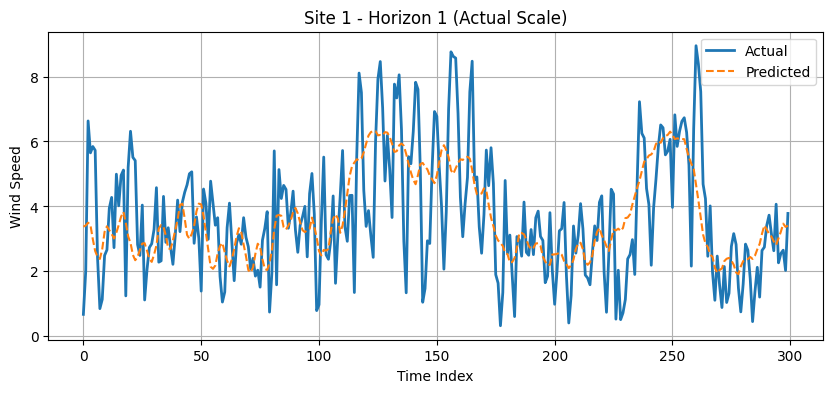

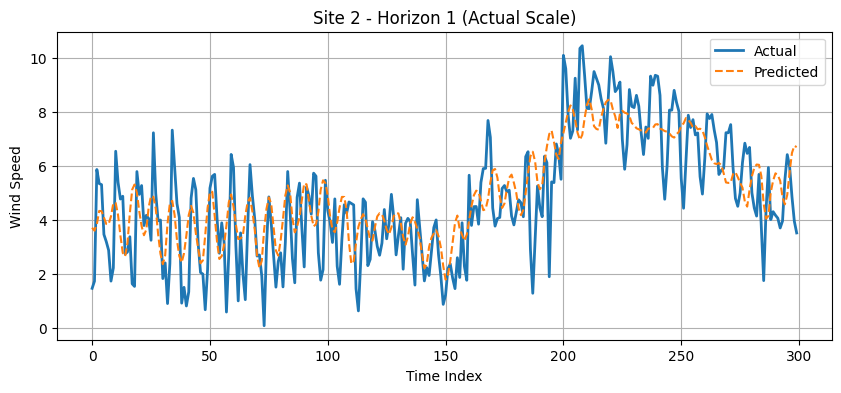

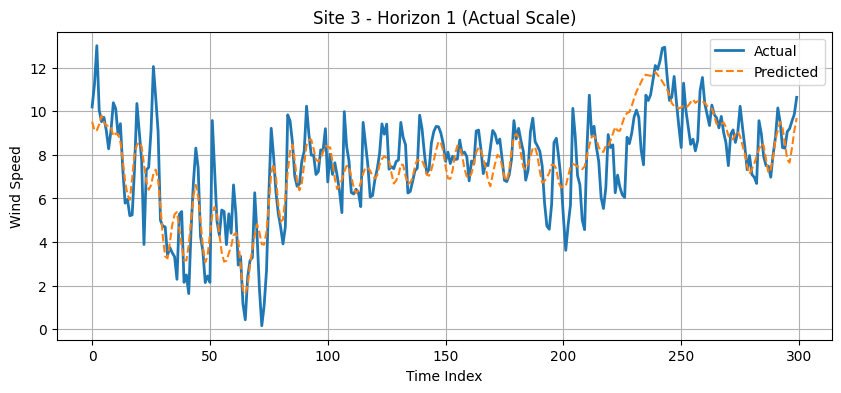

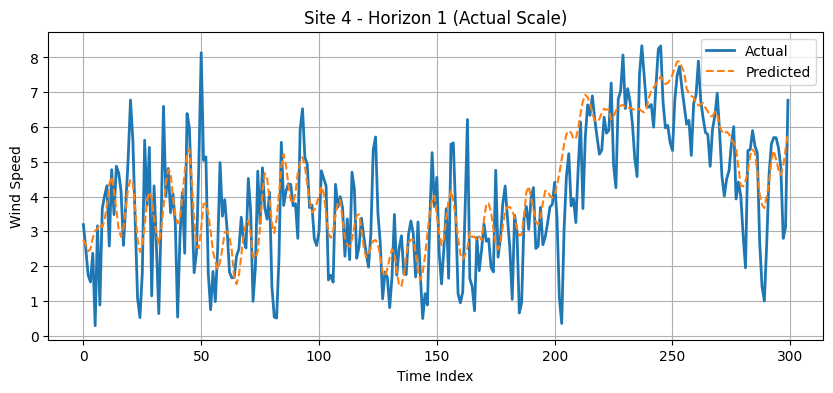

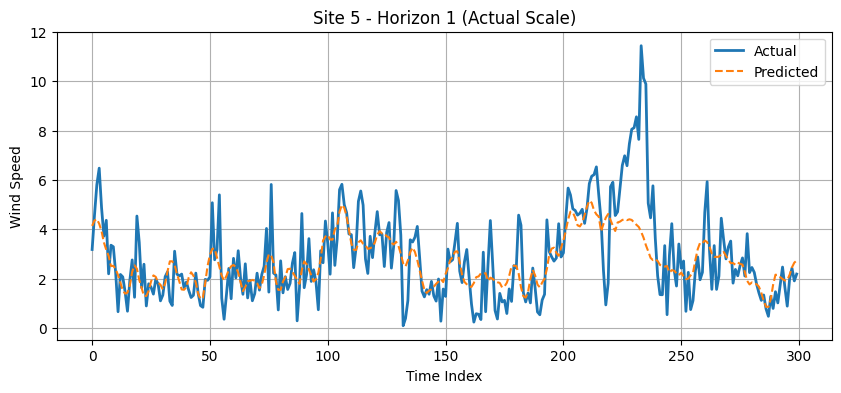

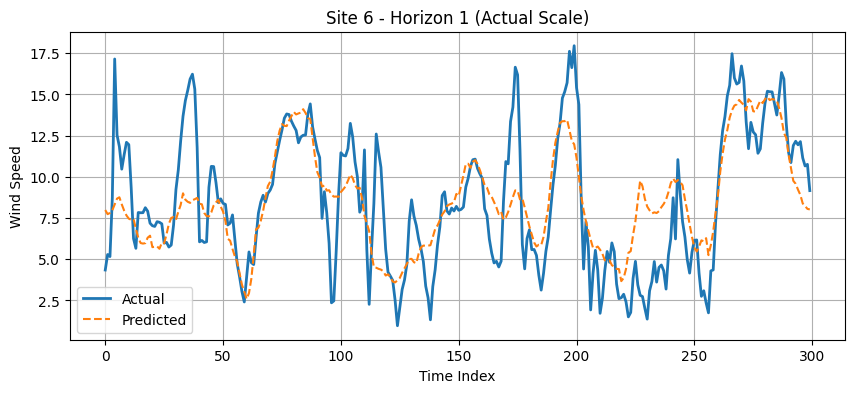

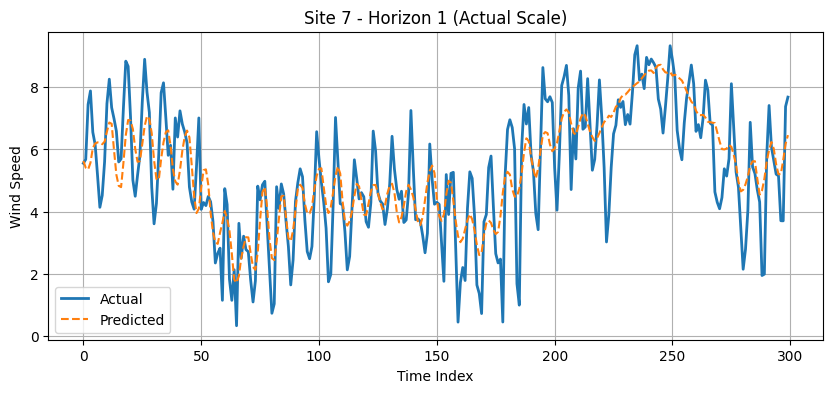

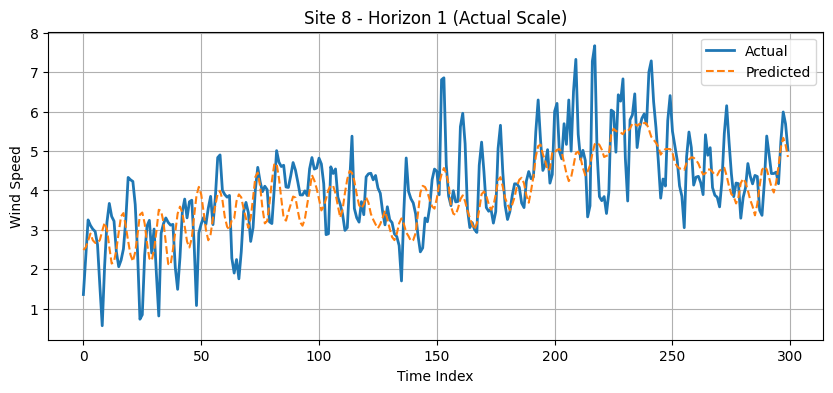

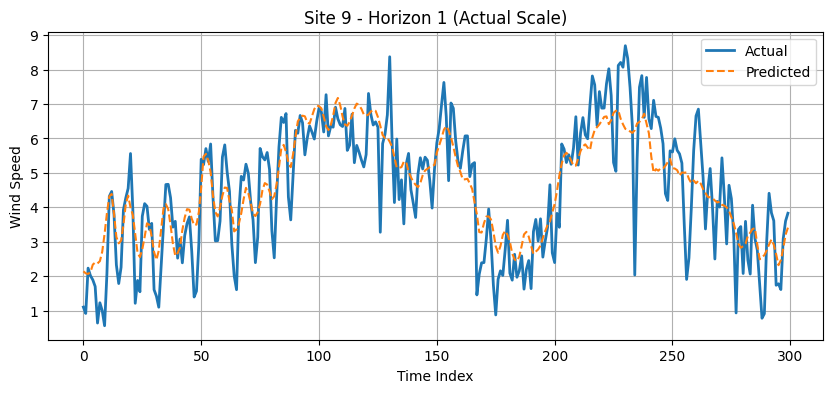

In [ ]:
import numpy as np

# copy to avoid overwriting
pred_denorm = pred_all.copy()
actual_denorm = actual_all.copy()

num_sites = pred_all.shape[2]

for i in range(num_sites):
    mean, std = wind_stats[i]

    pred_denorm[:, :, i] = pred_denorm[:, :, i] * std + mean
    actual_denorm[:, :, i] = actual_denorm[:, :, i] * std + mean

pred_h0 = pred_denorm[:, 1, :]      # horizon 1
actual_h0 = actual_denorm[:, 1, :]

import matplotlib.pyplot as plt

num_sites = pred_h0.shape[1]

for i in range(num_sites):

    plt.figure(figsize=(10, 4))

    plt.plot(actual_h0[:300, i], label="Actual", linewidth=2)
    plt.plot(pred_h0[:300, i], label="Predicted", linestyle="--")

    plt.title(f"Site {i+1} - Horizon 1 (Actual Scale)")
    plt.xlabel("Time Index")
    plt.ylabel("Wind Speed")

    plt.legend()
    plt.grid()

    plt.show()

#LSTM

In [ ]:
import torch
import numpy as np

class SingleSiteDataset(torch.utils.data.Dataset):

    def __init__(self, site_df):
        self.site_df = site_df

    def __len__(self):
        return len(self.site_df)

    def __getitem__(self, idx):

        # Input: past 48 timesteps
        wind_seq = self.site_df.iloc[idx, :48].values   # (48,)

        # reshape → (48, 1) for LSTM
        wind_seq = wind_seq.reshape(48, 1)

        # Target: next 7 steps
        target = self.site_df.iloc[idx, 48:55].values   # (7,)

        return (
            torch.tensor(wind_seq, dtype=torch.float32),  # (48, 1)
            torch.tensor(target, dtype=torch.float32)
        )

In [ ]:
# choose site (0 to 8)
site_index = 3

selected_site = site_sw_list[site_index]

dataset = SingleSiteDataset(selected_site)

In [ ]:
total_size = len(dataset)

train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)

train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
val_dataset   = torch.utils.data.Subset(dataset, range(train_size, train_size + val_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size + val_size, total_size))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,   # ONLY ONE SITE
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 7)

    def forward(self, x):

        # x: (B, 48, 1)
        out, _ = self.lstm(x)

        out = out[:, -1, :]   # last timestep

        out = self.fc(out)

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_losses = []
val_losses = []

epochs = 10

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 1 | Train: 5.4380 | Val: 2.0747
Epoch 2 | Train: 2.0526 | Val: 1.6640
Epoch 3 | Train: 1.8123 | Val: 1.5165
Epoch 4 | Train: 1.7001 | Val: 1.5699
Epoch 5 | Train: 1.6232 | Val: 1.3698
Epoch 6 | Train: 1.5192 | Val: 1.3356
Epoch 7 | Train: 1.4520 | Val: 1.3126
Epoch 8 | Train: 1.4192 | Val: 1.2746
Epoch 9 | Train: 1.3907 | Val: 1.2507
Epoch 10 | Train: 1.3717 | Val: 1.2184


In [ ]:
model.eval()

pred_list = []
actual_list = []

with torch.no_grad():
    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        pred = model(x)

        pred_list.append(pred.cpu())
        actual_list.append(y.cpu())

pred_all = torch.cat(pred_list).numpy()
actual_all = torch.cat(actual_list).numpy()

rmse = np.sqrt(np.mean((pred_all - actual_all)**2))
nrmse = rmse / (actual_all.max() - actual_all.min() + 1e-8)

print("Test RMSE :", rmse)
print("Test NRMSE:", nrmse)

Test RMSE : 1.0513694
Test NRMSE: 0.094546


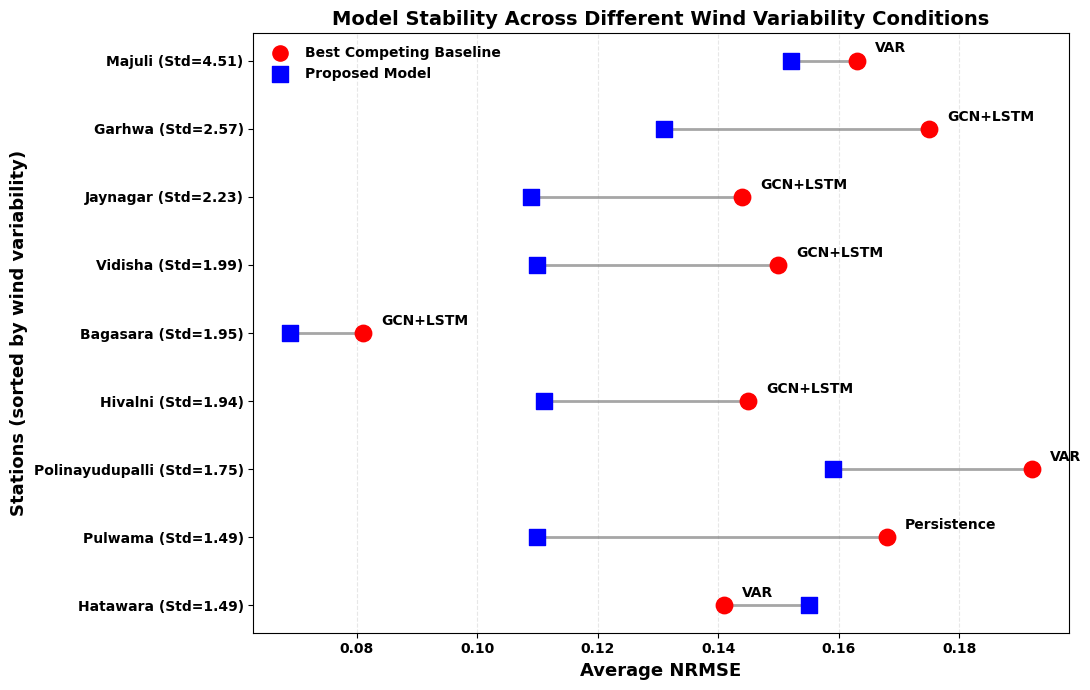

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# Data
# ==========================
data = {
    "Station": [
        "Hatawara",
        "Pulwama",
        "Polinayudupalli",
        "Hivalni",
        "Bagasara",
        "Vidisha",
        "Jaynagar",
        "Garhwa",
        "Majuli"
    ],

    "Std": [1.490, 1.490, 1.750, 1.941, 1.953, 1.991, 2.226, 2.573, 4.514],

    "Baseline_Model": [
        "VAR",
        "Persistence",
        "VAR",
        "GCN+LSTM",
        "GCN+LSTM",
        "GCN+LSTM",
        "GCN+LSTM",
        "GCN+LSTM",
        "VAR"
    ],

    "Baseline_NRMSE": [0.141, 0.168, 0.192, 0.145, 0.081, 0.150, 0.144, 0.175, 0.163],
    "Proposed_NRMSE": [0.155, 0.110, 0.159, 0.111, 0.069, 0.110, 0.109, 0.131, 0.152]
}

df = pd.DataFrame(data)

# Global bold font
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# ==========================
# Plot
# ==========================
fig, ax = plt.subplots(figsize=(11, 7), facecolor='white')
ax.set_facecolor('white')

y = np.arange(len(df))

# connecting lines
for i in range(len(df)):
    ax.plot(
        [df["Baseline_NRMSE"][i], df["Proposed_NRMSE"][i]],
        [y[i], y[i]],
        linewidth=2,
        color='gray',
        alpha=0.7
    )

# baseline points
ax.scatter(
    df["Baseline_NRMSE"],
    y,
    s=140,
    marker='o',
    color='red',
    zorder=3
)

# proposed points
ax.scatter(
    df["Proposed_NRMSE"],
    y,
    s=140,
    marker='s',
    color='blue',
    zorder=3
)

# annotate baseline names (bold)
for i in range(len(df)):
    ax.text(
        df["Baseline_NRMSE"][i] + 0.003,
        y[i] + 0.12,
        df["Baseline_Model"][i],
        fontsize=10,
        fontweight='bold'
    )

# bold y labels
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{s} (Std={v:.2f})" for s, v in zip(df["Station"], df["Std"])],
    fontsize=10,
    fontweight='bold'
)

# axis labels + title
ax.set_xlabel(
    "Average NRMSE",
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    "Stations (sorted by wind variability)",
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    "Model Stability Across Different Wind Variability Conditions",
    fontsize=14,
    fontweight='bold'
)

# bold x ticks
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')

# legend
ax.scatter([], [], color='red', s=120, label='Best Competing Baseline')
ax.scatter([], [], color='blue', marker='s', s=120, label='Proposed Model')

legend = ax.legend(frameon=False, prop={'weight':'bold', 'size':10})

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(
    "wind_variability_dumbbell_bold.png",
    dpi=600,
    facecolor='white',
    bbox_inches='tight'
)

plt.show()

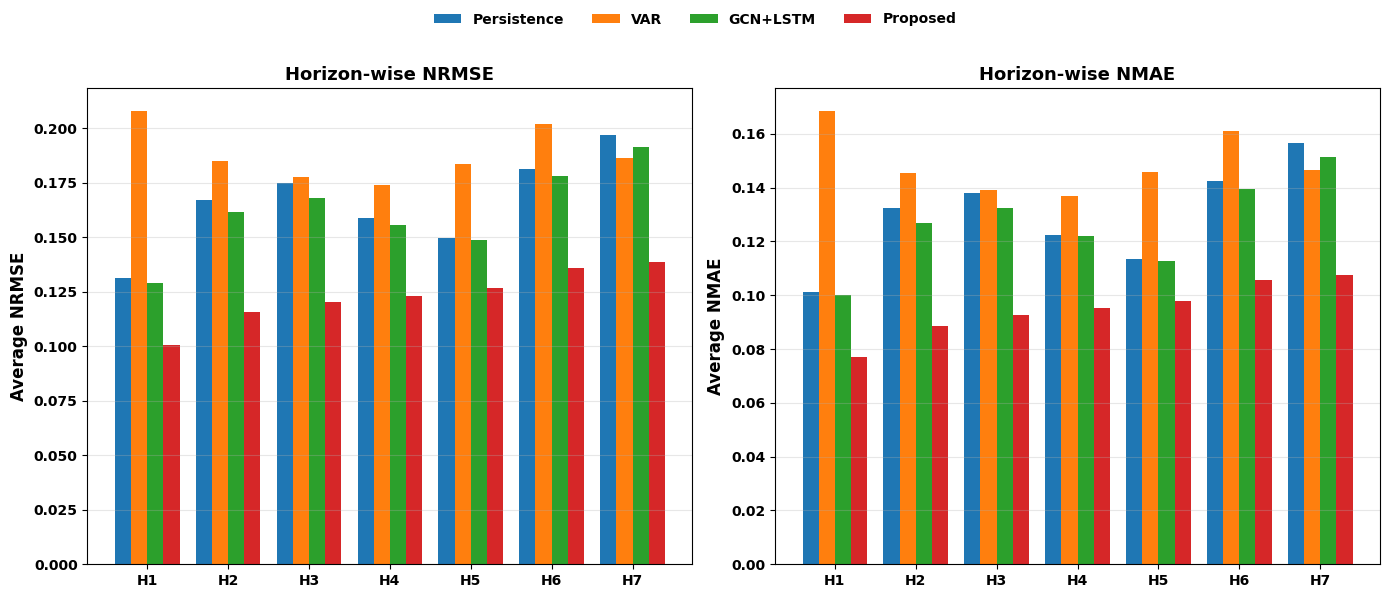

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Horizon-wise averages
# ==========================

horizons = ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7']

# ---------------- Proposed ----------------
prop_nrmse = [0.1004, 0.1159, 0.1202, 0.1233, 0.1270, 0.1361, 0.1388]
prop_nmae  = [0.0770, 0.0885, 0.0927, 0.0951, 0.0979, 0.1057, 0.1076]

# ---------------- Persistence ----------------
pers_nrmse = [0.1314, 0.1671, 0.1749, 0.1588, 0.1496, 0.1814, 0.1969]
pers_nmae  = [0.1013, 0.1326, 0.1380, 0.1225, 0.1136, 0.1425, 0.1566]

# ---------------- VAR ----------------
var_nrmse = [0.2080, 0.1852, 0.1779, 0.1740, 0.1839, 0.2022, 0.1866]
var_nmae  = [0.1685, 0.1453, 0.1391, 0.1368, 0.1458, 0.1612, 0.1464]

# ---------------- GCN+LSTM ----------------
gcn_nrmse = [0.1293, 0.1617, 0.1682, 0.1559, 0.1487, 0.1782, 0.1913]
gcn_nmae  = [0.1000, 0.1268, 0.1323, 0.1219, 0.1129, 0.1394, 0.1513]

# ==========================
# Plot
# ==========================
x = np.arange(len(horizons))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')

# -------- NRMSE --------
axes[0].bar(x - 1.5*width, pers_nrmse, width, label='Persistence')
axes[0].bar(x - 0.5*width, var_nrmse, width, label='VAR')
axes[0].bar(x + 0.5*width, gcn_nrmse, width, label='GCN+LSTM')
axes[0].bar(x + 1.5*width, prop_nrmse, width, label='Proposed')

axes[0].set_xticks(x)
axes[0].set_xticklabels(horizons, fontweight='bold')
axes[0].set_ylabel('Average NRMSE', fontsize=12, fontweight='bold')
axes[0].set_title('Horizon-wise NRMSE', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# -------- NMAE --------
axes[1].bar(x - 1.5*width, pers_nmae, width, label='Persistence')
axes[1].bar(x - 0.5*width, var_nmae, width, label='VAR')
axes[1].bar(x + 0.5*width, gcn_nmae, width, label='GCN+LSTM')
axes[1].bar(x + 1.5*width, prop_nmae, width, label='Proposed')

axes[1].set_xticks(x)
axes[1].set_xticklabels(horizons, fontweight='bold')
axes[1].set_ylabel('Average NMAE', fontsize=12, fontweight='bold')
axes[1].set_title('Horizon-wise NMAE', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    frameon=False,
    prop={'weight':'bold'}
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(
    'horizon_forecasting_quality.png',
    dpi=600,
    facecolor='white',
    bbox_inches='tight'
)

plt.show()

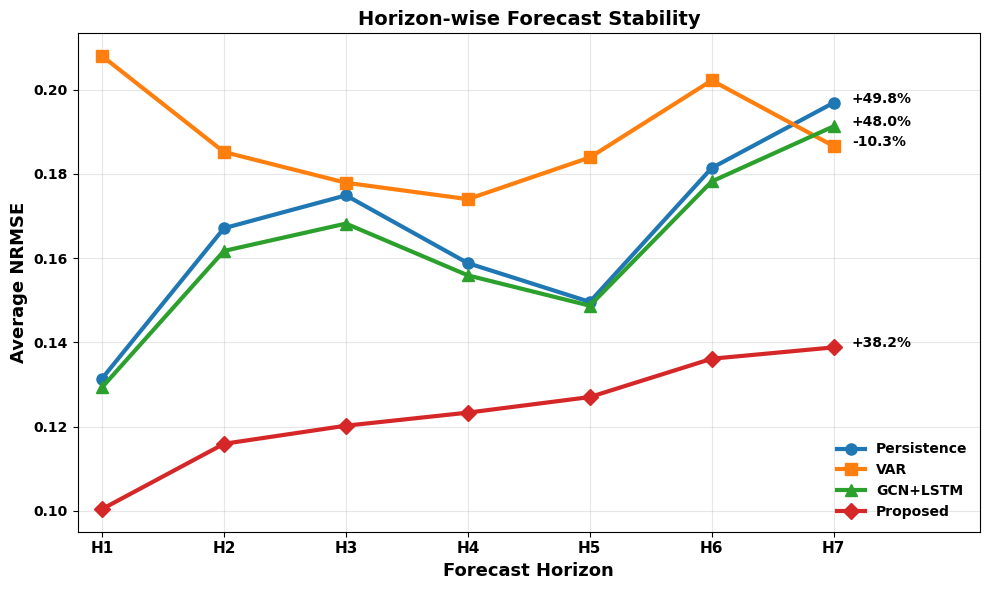

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Data
# ==========================
horizons = ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7']
x = np.arange(len(horizons))

pers = [0.1314, 0.1671, 0.1749, 0.1588, 0.1496, 0.1814, 0.1969]
var  = [0.2080, 0.1852, 0.1779, 0.1740, 0.1839, 0.2022, 0.1866]
gcn  = [0.1293, 0.1617, 0.1682, 0.1559, 0.1487, 0.1782, 0.1913]
prop = [0.1004, 0.1159, 0.1202, 0.1233, 0.1270, 0.1361, 0.1388]

# ==========================
# Plot
# ==========================
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

# Bold font globally
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Lines
ax.plot(x, pers, marker='o', linewidth=3, markersize=8, label='Persistence')
ax.plot(x, var, marker='s', linewidth=3, markersize=8, label='VAR')
ax.plot(x, gcn, marker='^', linewidth=3, markersize=8, label='GCN+LSTM')
ax.plot(x, prop, marker='D', linewidth=3, markersize=8, label='Proposed')

# degradation
def degradation(arr):
    return ((arr[-1] - arr[0]) / arr[0]) * 100

# safer annotation positions
offset_x = 0.15

ax.text(6 + offset_x, pers[-1], f"+{degradation(pers):.1f}%", fontsize=10, fontweight='bold')
ax.text(6 + offset_x, var[-1],  f"{degradation(var):.1f}%", fontsize=10, fontweight='bold')
ax.text(6 + offset_x, gcn[-1],  f"+{degradation(gcn):.1f}%", fontsize=10, fontweight='bold')
ax.text(6 + offset_x, prop[-1], f"+{degradation(prop):.1f}%", fontsize=10, fontweight='bold')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(horizons, fontsize=11, fontweight='bold')

ax.set_xlabel("Forecast Horizon", fontsize=13, fontweight='bold')
ax.set_ylabel("Average NRMSE", fontsize=13, fontweight='bold')
ax.set_title("Horizon-wise Forecast Stability", fontsize=14, fontweight='bold')

# Bold y ticks
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

# extra margin so text fits
ax.set_xlim(-0.2, 7.2)

ax.grid(alpha=0.3)
ax.legend(frameon=False, prop={'weight': 'bold', 'size': 10})

plt.tight_layout()

plt.savefig(
    "horizon_stability_plot.png",
    dpi=600,
    facecolor='white',
    bbox_inches='tight'
)

plt.show()

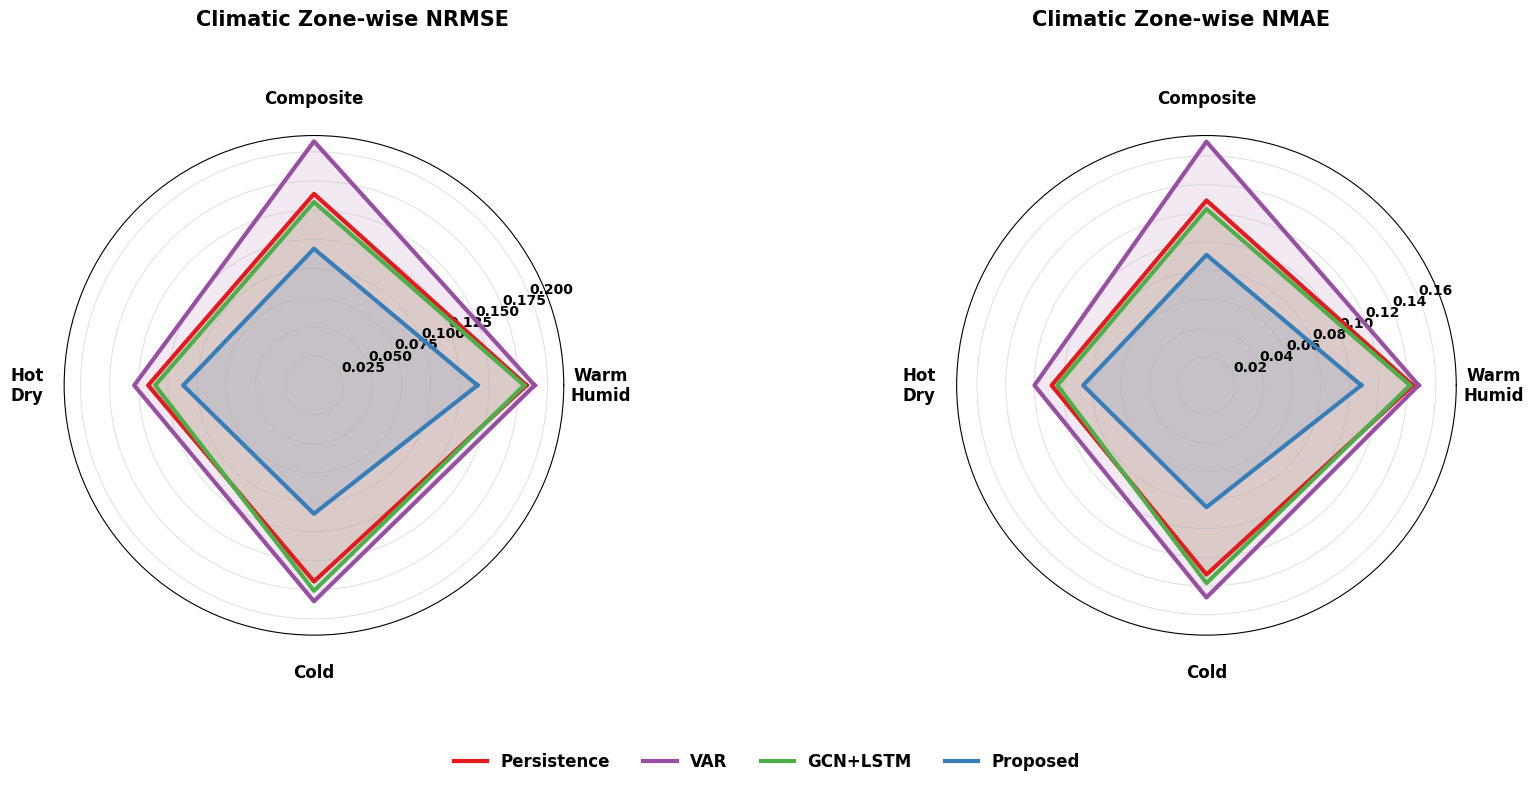

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# ==========================
# Zone-wise averages
# ==========================
zones = ['Warm\nHumid', 'Composite', 'Hot\nDry', 'Cold']

data = {
    'Persistence_NRMSE': [0.182, 0.164, 0.142, 0.168],
    'VAR_NRMSE':         [0.189, 0.209, 0.154, 0.185],
    'GCN_NRMSE':         [0.180, 0.157, 0.136, 0.176],
    'Proposed_NRMSE':    [0.140, 0.117, 0.112, 0.110],

    'Persistence_NMAE': [0.144, 0.129, 0.108, 0.132],
    'VAR_NMAE':         [0.148, 0.170, 0.120, 0.148],
    'GCN_NMAE':         [0.142, 0.123, 0.104, 0.138],
    'Proposed_NMAE':    [0.108, 0.091, 0.086, 0.085],
}

df = pd.DataFrame(data, index=zones)

# ==========================
# Strong distinct colors
# ==========================
colors = {
    'Persistence': '#E41A1C',   # strong red
    'VAR': '#984EA3',           # purple
    'GCN+LSTM': '#4DAF4A',      # green
    'Proposed': '#377EB8'       # blue
}

# ==========================
# Radar function
# ==========================
def radar_plot(ax, categories, model_data):
    N = len(categories)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    for label, values in model_data.items():
        vals = values + [values[0]]

        ax.plot(
            angles,
            vals,
            linewidth=3,
            color=colors[label]
        )

        ax.fill(
            angles,
            vals,
            color=colors[label],
            alpha=0.12
        )

    ax.set_xticks([])

    for angle, label in zip(angles[:-1], categories):
        ax.text(
            angle,
            ax.get_rmax() * 1.15,
            label,
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold'
        )

    for tick in ax.get_yticklabels():
        tick.set_fontsize(10)
        tick.set_fontweight('bold')

    ax.grid(alpha=0.35)

# ==========================
# Plot
# ==========================
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 8),
    subplot_kw=dict(polar=True),
    facecolor='white'
)

for ax in axes:
    ax.set_facecolor('white')

# Left radar
radar_plot(
    axes[0],
    zones,
    {
        'Persistence': df['Persistence_NRMSE'].tolist(),
        'VAR': df['VAR_NRMSE'].tolist(),
        'GCN+LSTM': df['GCN_NRMSE'].tolist(),
        'Proposed': df['Proposed_NRMSE'].tolist()
    }
)

# Right radar
radar_plot(
    axes[1],
    zones,
    {
        'Persistence': df['Persistence_NMAE'].tolist(),
        'VAR': df['VAR_NMAE'].tolist(),
        'GCN+LSTM': df['GCN_NMAE'].tolist(),
        'Proposed': df['Proposed_NMAE'].tolist()
    }
)

# Figure-level titles OUTSIDE plots
fig.text(
    0.27,
    0.93,
    "Climatic Zone-wise NRMSE",
    ha='center',
    fontsize=15,
    fontweight='bold'
)

fig.text(
    0.73,
    0.93,
    "Climatic Zone-wise NMAE",
    ha='center',
    fontsize=15,
    fontweight='bold'
)

# Clean legend
legend_elements = [
    Line2D([0], [0], color=colors['Persistence'], lw=3, label='Persistence'),
    Line2D([0], [0], color=colors['VAR'], lw=3, label='VAR'),
    Line2D([0], [0], color=colors['GCN+LSTM'], lw=3, label='GCN+LSTM'),
    Line2D([0], [0], color=colors['Proposed'], lw=3, label='Proposed')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False,
    prop={'weight':'bold', 'size':12}
)

plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    'climatic_zone_radar_final.png',
    dpi=600,
    facecolor='white',
    bbox_inches='tight'
)

plt.show()

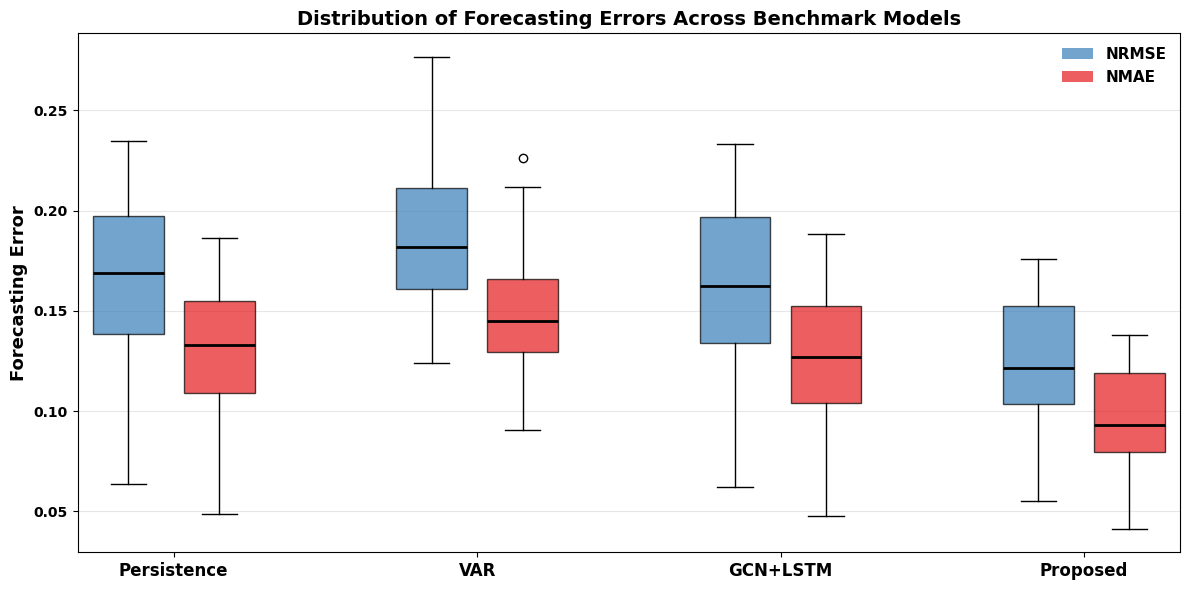

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# Data
# ==========================
models = ['Persistence', 'VAR', 'GCN+LSTM', 'Proposed']

nrmse_data = [persistence, var, gcn, proposed]
nmae_data = [persistence_nmae, var_nmae, gcn_nmae, proposed_nmae]

# ==========================
# Plot
# ==========================
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

positions_nrmse = np.array([1, 4, 7, 10])
positions_nmae = positions_nrmse + 0.9

# colors
nrmse_color = '#377EB8'   # blue
nmae_color = '#E41A1C'    # red

# NRMSE boxes
box1 = ax.boxplot(
    nrmse_data,
    positions=positions_nrmse,
    widths=0.7,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

# NMAE boxes
box2 = ax.boxplot(
    nmae_data,
    positions=positions_nmae,
    widths=0.7,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

# color fill
for patch in box1['boxes']:
    patch.set_facecolor(nrmse_color)
    patch.set_alpha(0.7)

for patch in box2['boxes']:
    patch.set_facecolor(nmae_color)
    patch.set_alpha(0.7)

# x labels
ax.set_xticks(positions_nrmse + 0.45)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')

# y labels
ax.set_ylabel("Forecasting Error", fontsize=13, fontweight='bold')

# title
ax.set_title(
    "Distribution of Forecasting Errors Across Benchmark Models",
    fontsize=14,
    fontweight='bold'
)

# bold y ticks
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

# legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=nrmse_color, alpha=0.7, label='NRMSE'),
    Patch(facecolor=nmae_color, alpha=0.7, label='NMAE')
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    prop={'weight':'bold', 'size':11}
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "benchmark_dual_boxplot.png",
    dpi=600,
    facecolor='white',
    bbox_inches='tight'
)

plt.show()